# ATIS Intent Classification — Full Analysis

> **Dataset**: `tuetschek/atis` (Hugging Face)  
> **Task**: Multi-class intent classification (18 classes)  
> **Baseline**: TF-IDF + Logistic Regression  
> **Tables**: II (Distribution) · IV (Classification Report) · V (Ablation Study)

---
## 1 · Load & Prepare ATIS Dataset

In [1]:
!pip install -q datasets scikit-learn pandas matplotlib

In [2]:
import warnings
warnings.filterwarnings('ignore')

import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score
)

pd.set_option('display.max_colwidth', 80)
print('✅  Imports OK')

✅  Imports OK


In [3]:
# ── Intent index → label mapping ──────────────────────────────────────────
# The HuggingFace version encodes intents as integers; map them to strings.
# Labels are taken from the dataset's ClassLabel feature.

ATIS_INTENT_MAPPING = {
    'abbreviation': "Abbreviation and Fare Code Meaning Inquiry",
    'aircraft':     "Aircraft Type Inquiry",
    'airfare':      "Airfare and Fares Questions",
    'airline':      "Airline Information Request",
    'airport':      "Airport Information and Queries",
    'capacity':     "Aircraft Seating Capacity Inquiry",
    'cheapest':     "Cheapest Fare Inquiry",
    'city':         "Airport Location Inquiry",
    'day_name':     "The Name of Day",
    'distance':     "Airport Distance Inquiry",
    'flight':       "Flight Booking Request",
    'flight_no':    "Flight Number Inquiry",
    'flight_time':  "Time Inquiry",
    'ground_fare':  "Ground Transportation Cost Inquiry",
    'ground_service': "Ground Transportation Inquiry",
    'meal':         "Inquiry about In-flight Meals",
    'quantity':     "Flight Quantity Inquiry",
    'restriction':  "Flight Restriction Inquiry",
}

print(f'Mapping covers {len(ATIS_INTENT_MAPPING)} intent classes')

Mapping covers 18 intent classes


In [4]:
print("Loading ATIS dataset from Hugging Face...")
dataset = load_dataset("tuetschek/atis")
dataset.set_format(type="pandas")

df_all_train  = dataset["train"][:]
df_test_raw  = dataset["test"][:]

df_all_train["label"] = df_all_train["intent"].apply(lambda x: ATIS_INTENT_MAPPING.get(x))
df_test_raw["label"] = df_test_raw["intent"].apply(lambda x: ATIS_INTENT_MAPPING.get(x))

df_all_train.dropna(subset=["label"], inplace=True)
df_test_raw.dropna(subset=["label"], inplace=True)

df_train, df_valid = train_test_split(df_all_train, test_size=0.15, random_state=42)

print(f"Train samples  : {len(df_train)}")
print(f"Valid samples  : {len(df_valid)}")
print(f"Test  samples  : {len(df_test_raw)}")
print(f"Intent categories: {df_train['intent'].nunique()}")
display(df_train.head(3))

Loading ATIS dataset from Hugging Face...


atis_train.csv:   0%|          | 0.00/850k [00:00<?, ?B/s]

atis_test.csv:   0%|          | 0.00/144k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/893 [00:00<?, ? examples/s]

Train samples  : 4209
Valid samples  : 743
Test  samples  : 878
Intent categories: 17


,id,intent,text,slots,label
1571,1571,flight,show me the cheapest flights from baltimore to dallas,O O O B-cost_relative O O B-fromloc.city_name O B-toloc.city_name,Flight Booking Request
3722,3722,flight,list flights between denver and pittsburgh,O O O B-fromloc.city_name O B-toloc.city_name,Flight Booking Request
3454,3454,flight,on april fifteenth i would like an early morning flight from boston to atlanta,O B-depart_date.month_name B-depart_date.day_number O O O O B-depart_time.pe...,Flight Booking Request


---
## 2 · TABLE II — ATIS Intent Category Distribution

In [5]:
# ── Compute distribution from actual split data ───────────────────────────
train_counts = df_train['label'].value_counts().rename('Training Samples')
test_counts  = df_test_raw['label'].value_counts().rename('Test Samples')

df_t2 = (
    pd.concat([train_counts, test_counts], axis=1)
    .fillna(0)
    .astype({'Training Samples': int, 'Test Samples': int})
    .sort_values('Training Samples', ascending=False)
    .reset_index()
    .rename(columns={'index': 'Intent Label'})
)

total_train = df_t2['Training Samples'].sum()
df_t2['Relative Frequency (%)'] = (
    df_t2['Training Samples'] / total_train * 100
).map(lambda x: f'{x:.2f}%')

# Append TOTAL row
total_row = pd.DataFrame([{
    'Intent Label': 'TOTAL',
    'Training Samples': df_t2['Training Samples'].sum(),
    'Test Samples':     df_t2['Test Samples'].sum(),
    'Relative Frequency (%)': '100.00%'
}])
df_t2_display = pd.concat([df_t2, total_row], ignore_index=True)
print(f'Computed from real split — {len(df_t2)} intent classes')

Computed from real split — 18 intent classes


In [6]:
def style_table2(df):
    def row_bg(row):
        if row['Intent Label'] == 'TOTAL':
            return [
                'background-color: #1F3864; color: white; font-weight: bold'
            ] * len(row)
        try:
            v = int(str(row['Training Samples']).replace(',', ''))
        except ValueError:
            return [''] * len(row)

        if v >= 400:
            return ['background-color: #1E7B34; color: white; font-weight: 600'] * len(row)
        elif v >= 50:
            return ['background-color: #B8860B; color: white; font-weight: 600'] * len(row)
        elif v >= 10:
            return ['background-color: #CC3300; color: white; font-weight: 600'] * len(row)
        else:
            return ['background-color: #7B0000; color: white; font-weight: 600'] * len(row)

    return (
        df.style
          .apply(row_bg, axis=1)
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '14px'), ('font-weight', 'bold'),
                         ('padding', '10px 0'), ('color', '#1F3864'),
                         ('caption-side', 'top')]},
              {'selector': 'thead th',
               'props': [('background-color', '#1F3864'), ('color', 'white'),
                         ('font-weight', 'bold'), ('font-size', '13px'),
                         ('text-align', 'center'), ('padding', '10px 14px'),
                         ('border', '1px solid #999')]},
              {'selector': 'td',
               'props': [('font-size', '12px'), ('padding', '7px 14px'),
                         ('border', '1px solid #ccc'), ('text-align', 'center')]},
              {'selector': 'tr:hover td',
               'props': [('filter', 'brightness(0.92)')]},
              {'selector': '',
               'props': [('border-collapse', 'collapse'), ('width', '100%')]},
          ])
          .set_caption(
              'TABLE II. ATIS Intent Category Distribution  '
              '(🟢 Majority ≥400  |  🟡 Moderate ≥50  |  🔴 Low ≥10  |  ❗ Critical <10)'
          )
          .format({'Training Samples': '{:,}', 'Test Samples': '{:,}'})
          .hide(axis='index')
    )

display(style_table2(df_t2_display))

label,Training Samples,Test Samples,Relative Frequency (%),Intent Label
Flight Booking Request,"3,112",632,73.94%,nan
Airfare and Fares Questions,356,48,8.46%,nan
Ground Transportation Inquiry,224,36,5.32%,nan
Abbreviation and Fare Code Meaning Inquiry,128,33,3.04%,nan
Airline Information Request,126,38,2.99%,nan
Aircraft Type Inquiry,70,9,1.66%,nan
Flight Quantity Inquiry,46,3,1.09%,nan
Time Inquiry,46,1,1.09%,nan
Airport Distance Inquiry,18,10,0.43%,nan
Airport Location Inquiry,16,6,0.38%,nan


In [7]:
labels  = df_t2['label'].tolist()
tr_vals = df_t2['Training Samples'].tolist()
te_vals = df_t2['Test Samples'].tolist()
colours = ['#1a7a4a' if v>=400 else '#c87f00' if v>=50
           else '#cc3300' if v>=10 else '#800000' for v in tr_vals]

x, bar_w = range(len(labels)), 0.42
fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.barh([i+bar_w/2 for i in x], tr_vals, height=bar_w,
             color=colours, alpha=0.85, label='Training')
b2 = ax.barh([i-bar_w/2 for i in x], te_vals, height=bar_w,
             color='#4472C4', alpha=0.70, label='Test')
ax.set_yticks(list(x)); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Sample count', fontsize=12)
ax.set_title('TABLE II — ATIS Intent Category Distribution\n(Training vs Test per class)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xscale('log'); ax.set_xlim(0.8, 6000)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(b1, tr_vals):
    ax.text(val*1.08, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
for bar, val in zip(b2, te_vals):
    lbl = str(val) if val > 0 else '0'
    ax.text(max(val,1)*1.08, bar.get_y()+bar.get_height()/2,
            lbl, va='center', fontsize=8, color='#333' if val>0 else '#999')
plt.tight_layout()
plt.savefig('table2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: table2_distribution.png')

Saved: table2_distribution.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# ATIS — Flexible Charting Functions
# Three functions, one per table, each supporting multiple chart types.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


# ───────────────────────────────────────────────────────────────────────────
# SHARED PALETTE
# ───────────────────────────────────────────────────────────────────────────
PALETTE = {
    'majority':  '#1E7B34',   # green  — ≥ 400
    'moderate':  '#B8860B',   # amber  — ≥ 50
    'low':       '#CC3300',   # red    — ≥ 10
    'critical':  '#7B0000',   # dark   — < 10
    'train':     '#4472C4',   # blue
    'test':      '#ED7D31',   # orange
    'f1_high':   '#1E7B34',   # green  — F1 ≥ 0.80
    'f1_mid':    '#B8860B',   # amber  — F1 ≥ 0.50
    'f1_low':    '#CC3300',   # red    — F1 < 0.50
    'accuracy':  '#2E75B6',
    'macro_f1':  '#C55A11',
    'baseline':  '#7030A0',
}

def _class_colour(train_count):
    if train_count >= 400: return PALETTE['majority']
    if train_count >= 50:  return PALETTE['moderate']
    if train_count >= 10:  return PALETTE['low']
    return PALETTE['critical']

def _f1_colour(f1):
    if f1 >= 0.80: return PALETTE['f1_high']
    if f1 >= 0.50: return PALETTE['f1_mid']
    return PALETTE['f1_low']

def _legend_patches(include_train_test=False, include_f1=False, include_class=False):
    patches = []
    if include_class or include_train_test:
        patches += [
            mpatches.Patch(color=PALETTE['majority'], label='Majority ≥ 400'),
            mpatches.Patch(color=PALETTE['moderate'], label='Moderate ≥ 50'),
            mpatches.Patch(color=PALETTE['low'],      label='Low ≥ 10'),
            mpatches.Patch(color=PALETTE['critical'], label='Critical < 10'),
        ]
    if include_f1:
        patches += [
            mpatches.Patch(color=PALETTE['f1_high'], label='F1 ≥ 0.80'),
            mpatches.Patch(color=PALETTE['f1_mid'],  label='F1 ≥ 0.50'),
            mpatches.Patch(color=PALETTE['f1_low'],  label='F1 < 0.50'),
        ]
    return patches

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 1 — TABLE II: Intent Distribution
# ═══════════════════════════════════════════════════════════════════════════
def plot_table2_distribution(
    df_t2,
    chart_type='grouped_bar',      # 'grouped_bar' | 'stacked_bar' | 'horizontal_bar'
                                   # | 'lollipop' | 'area' | 'pie' | 'donut'
    scale='log',                   # 'log' | 'linear'
    figsize=None,
    color_by='class_size',         # 'class_size' | 'split' (train vs test)
    show_values=True,
    show_legend=True,
    title=None,
    save_path=None,
    dpi=150,
):
    """
    Visualise TABLE II — ATIS intent category distribution.

    Parameters
    ----------
    df_t2        : DataFrame with columns ['Intent Label','Training Samples','Test Samples']
    chart_type   : 'grouped_bar'   — side-by-side horizontal bars (default)
                   'stacked_bar'   — stacked horizontal bars
                   'horizontal_bar'— single train-only bar
                   'lollipop'      — lollipop / dot-stem chart
                   'area'          — area/line chart (sorted by frequency)
                   'pie'           — pie chart of training distribution
                   'donut'         — donut chart of training distribution
    scale        : 'log' or 'linear' (ignored for pie/donut)
    color_by     : 'class_size' colours bars by majority/moderate/low/critical
                   'split'      colours train blue / test orange
    """
    # ── Data prep ──────────────────────────────────────────────────────────
    df = df_t2[df_t2['Intent Label'] != 'TOTAL'].copy()
    df = df.sort_values('Training Samples', ascending=True)
    labels    = df['Intent Label'].tolist()
    tr_vals   = df['Training Samples'].tolist()
    te_vals   = df['Test Samples'].tolist()
    n         = len(labels)

    if color_by == 'class_size':
        colours = [_class_colour(v) for v in tr_vals]
    else:
        colours = [PALETTE['train']] * n

    default_title = title or 'TABLE II — ATIS Intent Category Distribution'
    fs = figsize or (14, max(7, n * 0.45))

    # ── PIE / DONUT ────────────────────────────────────────────────────────
    if chart_type in ('pie', 'donut'):
        fig, ax = plt.subplots(figsize=(10, 10))
        wedge_colours = [_class_colour(v) for v in tr_vals]
        wedge_props   = dict(width=0.5) if chart_type == 'donut' else {}
        wedges, texts, autotexts = ax.pie(
            tr_vals, labels=labels, colors=wedge_colours,
            autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
            startangle=140, pctdistance=0.80,
            textprops={'fontsize': 9},
            **wedge_props
        )
        for at in autotexts:
            at.set_color('white'); at.set_fontweight('bold')
        if chart_type == 'donut':
            ax.text(0, 0, f'{sum(tr_vals):,}\nsamples',
                    ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_title(default_title, fontsize=14, fontweight='bold', pad=20)
        if show_legend:
            ax.legend(handles=_legend_patches(include_class=True),
                      loc='lower left', fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── AREA / LINE ────────────────────────────────────────────────────────
    if chart_type == 'area':
        df_area = df.sort_values('Training Samples', ascending=False).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=fs)
        x = range(len(df_area))
        ax.fill_between(x, df_area['Training Samples'], alpha=0.4,
                        color=PALETTE['train'], label='Training')
        ax.fill_between(x, df_area['Test Samples'], alpha=0.5,
                        color=PALETTE['test'],  label='Test')
        ax.plot(x, df_area['Training Samples'], 'o-',
                color=PALETTE['train'], linewidth=2, markersize=5)
        ax.plot(x, df_area['Test Samples'], 's--',
                color=PALETTE['test'],  linewidth=1.5, markersize=4)
        ax.set_xticks(list(x))
        ax.set_xticklabels(df_area['Intent Label'], rotation=45, ha='right', fontsize=9)
        if scale == 'log': ax.set_yscale('log')
        ax.set_ylabel('Sample count', fontsize=12)
        ax.set_title(default_title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── LOLLIPOP ───────────────────────────────────────────────────────────
    if chart_type == 'lollipop':
        fig, ax = plt.subplots(figsize=fs)
        y = range(n)
        for i, (lbl, tv, col) in enumerate(zip(labels, tr_vals, colours)):
            ax.hlines(i, 0, tv, colors=col, linewidth=2, alpha=0.7)
            ax.plot(tv, i, 'o', color=col, markersize=10, zorder=5)
            if show_values:
                ax.text(tv * (1.05 if scale == 'log' else 1) + (0 if scale == 'log' else 5),
                        i, f'{tv:,}', va='center', fontsize=8)
        ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=10)
        if scale == 'log': ax.set_xscale('log'); ax.set_xlim(0.8, max(tr_vals)*3)
        ax.set_xlabel('Training samples', fontsize=12)
        ax.set_title(default_title, fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        if show_legend:
            ax.legend(handles=_legend_patches(include_class=True), fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── SINGLE HORIZONTAL BAR (train only) ────────────────────────────────
    if chart_type == 'horizontal_bar':
        fig, ax = plt.subplots(figsize=fs)
        bars = ax.barh(labels, tr_vals, color=colours, alpha=0.88)
        if scale == 'log': ax.set_xscale('log'); ax.set_xlim(0.8, max(tr_vals)*3)
        if show_values:
            for bar, val in zip(bars, tr_vals):
                ax.text(val*(1.08 if scale=='log' else 1)+2,
                        bar.get_y()+bar.get_height()/2,
                        f'{val:,}', va='center', fontsize=8)
        ax.set_xlabel('Training samples', fontsize=12)
        ax.set_title(default_title, fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        if show_legend:
            ax.legend(handles=_legend_patches(include_class=True), fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── STACKED BAR ────────────────────────────────────────────────────────
    if chart_type == 'stacked_bar':
        fig, ax = plt.subplots(figsize=fs)
        bar_colours = colours if color_by == 'class_size' else [PALETTE['train']]*n
        ax.barh(labels, tr_vals, color=bar_colours, alpha=0.85, label='Training')
        ax.barh(labels, te_vals, left=tr_vals,
                color=PALETTE['test'], alpha=0.70, label='Test')
        if scale == 'log': ax.set_xscale('log')
        ax.set_xlabel('Sample count', fontsize=12)
        ax.set_title(default_title, fontsize=13, fontweight='bold')
        if show_legend: ax.legend(fontsize=10)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── GROUPED BAR (default) ──────────────────────────────────────────────
    bar_w = 0.42
    y     = range(n)
    bar_colours = colours if color_by == 'class_size' else [PALETTE['train']]*n

    fig, ax = plt.subplots(figsize=fs)
    b1 = ax.barh([i+bar_w/2 for i in y], tr_vals,
                 height=bar_w, color=bar_colours, alpha=0.85, label='Training')
    b2 = ax.barh([i-bar_w/2 for i in y], te_vals,
                 height=bar_w, color=PALETTE['test'], alpha=0.70, label='Test')
    ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=10)
    if scale == 'log': ax.set_xscale('log'); ax.set_xlim(0.8, max(tr_vals)*3)
    ax.set_xlabel('Sample count', fontsize=12)
    ax.set_title(default_title + '\n(Training vs Test per class)',
                 fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    if show_values:
        for bar, val in zip(b1, tr_vals):
            ax.text(val*(1.08 if scale=='log' else 1)+1,
                    bar.get_y()+bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=8)
        for bar, val in zip(b2, te_vals):
            x_pos = max(val, 1)*(1.08 if scale=='log' else 1)
            ax.text(x_pos, bar.get_y()+bar.get_height()/2,
                    str(val) if val>0 else '0',
                    va='center', fontsize=8,
                    color='#333' if val>0 else '#999')
    handles = [
        mpatches.Patch(color=PALETTE['test'],  label='Test'),
    ] + _legend_patches(include_class=True)
    train_patch = mpatches.Patch(color=bar_colours[-1], label='Training (colour = class size)')
    if show_legend:
        ax.legend(handles=[train_patch] + handles, fontsize=9, loc='lower right')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()


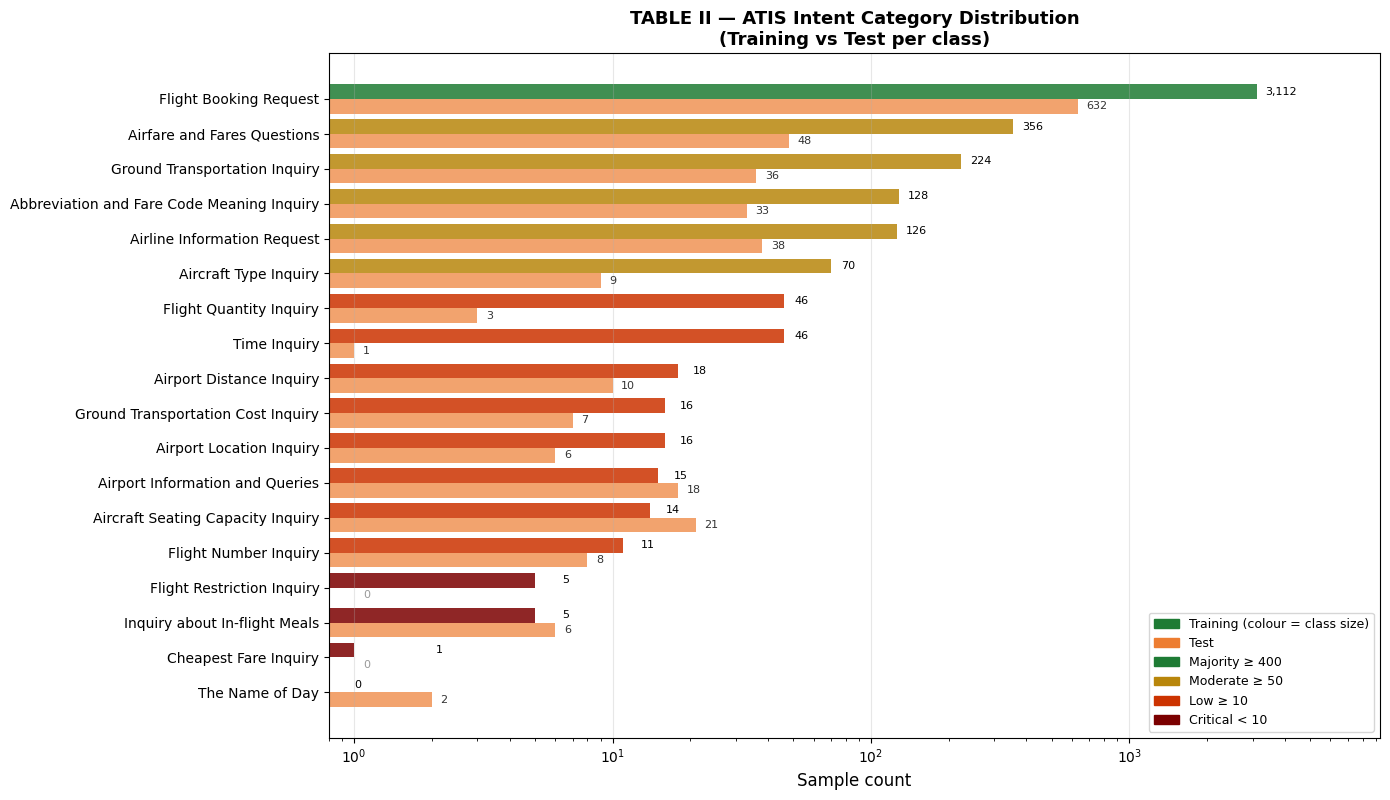

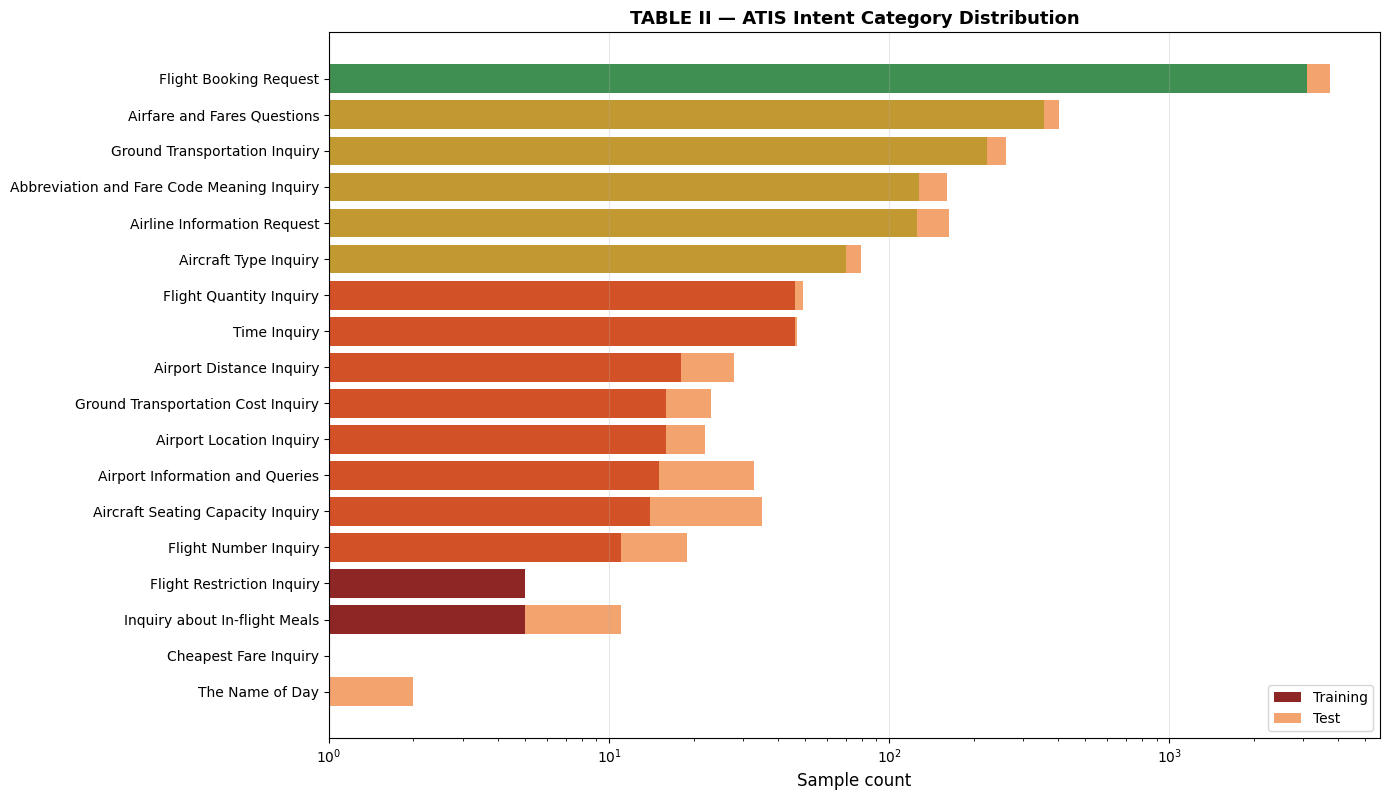

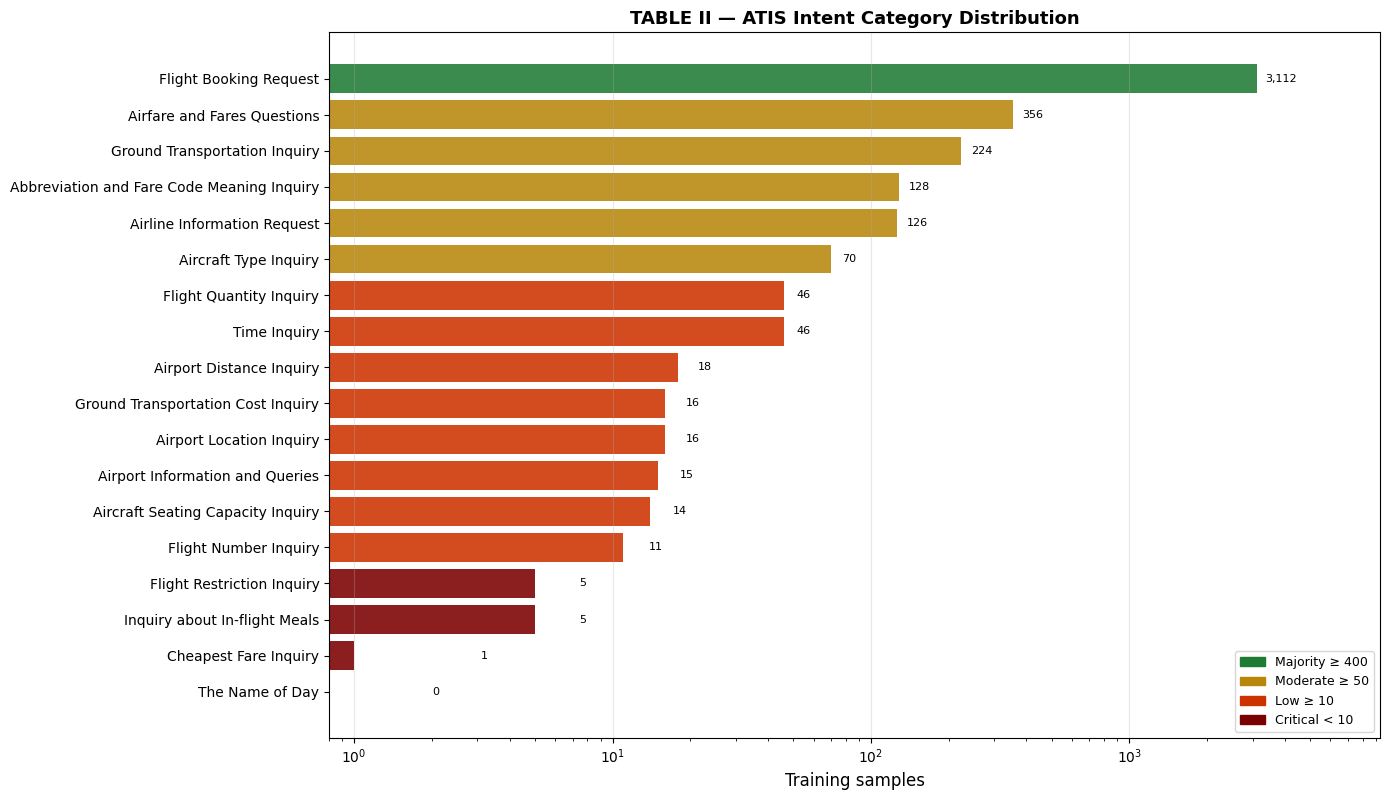

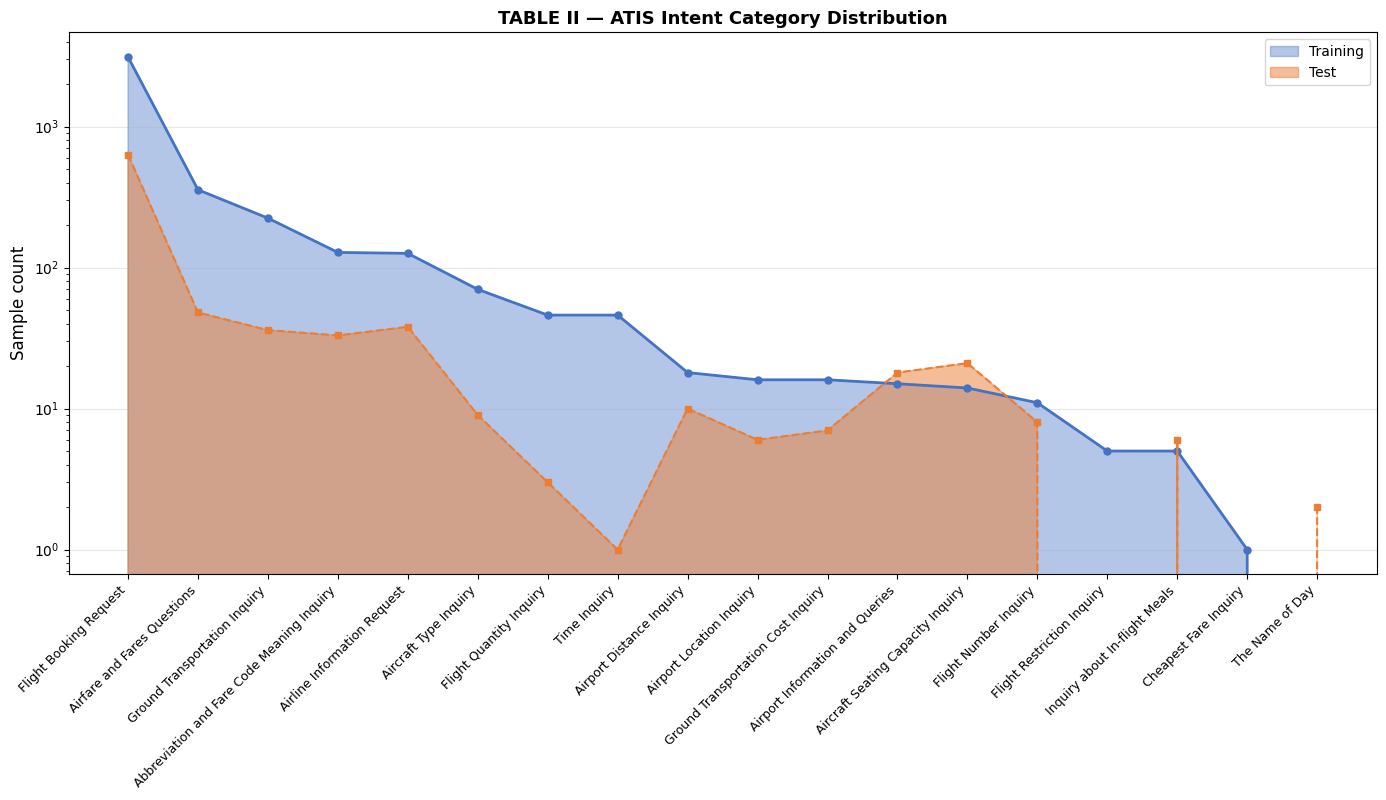

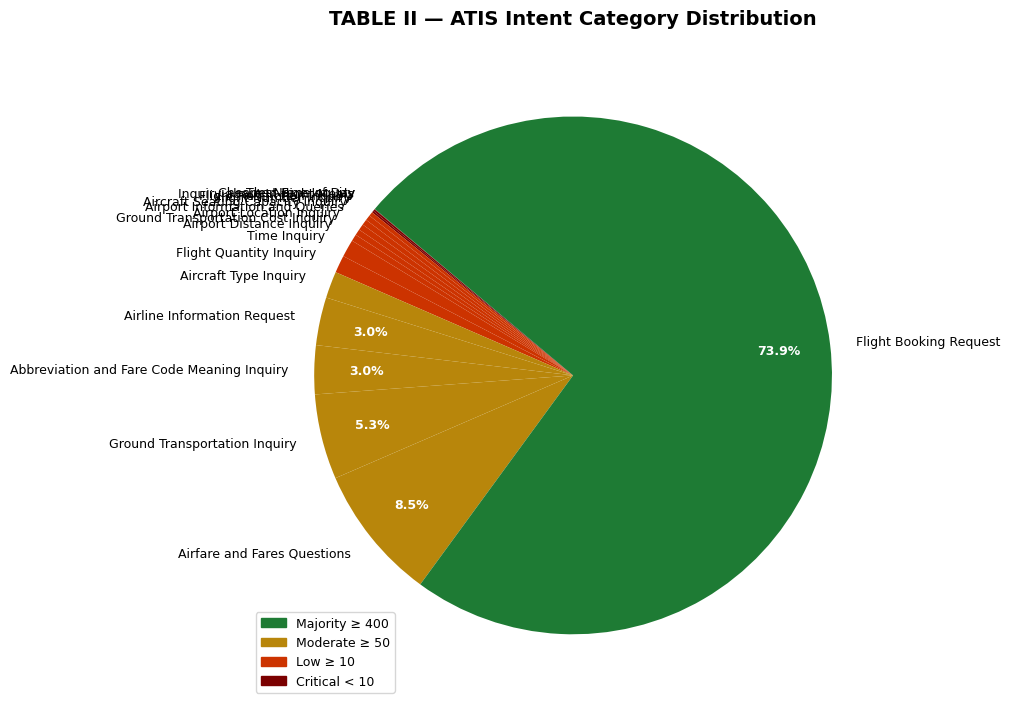

In [10]:
df_t2_for_plot = df_t2.rename(columns={'label': 'Intent Label'})

plot_table2_distribution(df_t2_for_plot, chart_type='grouped_bar')     # default
plot_table2_distribution(df_t2_for_plot, chart_type='stacked_bar')
plot_table2_distribution(df_t2_for_plot, chart_type='horizontal_bar')  # train only
plot_table2_distribution(df_t2_for_plot, chart_type='lollipop')
plot_table2_distribution(df_t2_for_plot, chart_type='area')
plot_table2_distribution(df_t2_for_plot, chart_type='pie')
# plot_table2_distribution(df_t2_for_plot, chart_type='donut')
# Extra options: scale='linear', color_by='split', show_values=False, save_path='fig.png'

---
## 3 · TABLE IV — Per-Class Classification Report
### TF-IDF + Logistic Regression (Full ATIS Test Set)

In [11]:
# ── Train baseline model ──────────────────────────────────────────────────
vectorizer = TfidfVectorizer(sublinear_tf=True)
X_train = vectorizer.fit_transform(df_train['text'])
X_test  = vectorizer.transform(df_test_raw['text'])
y_train = df_train['label']
y_test  = df_test_raw['label']

clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
macro  = f1_score(y_test, y_pred, average='macro',    zero_division=0)
weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f'Accuracy   : {acc:.4f}')
print(f'Macro-F1   : {macro:.4f}')
print(f'Weighted-F1: {weighted:.4f}')


# # ── Train baseline model ──────────────────────────────────────────────────
# # TEXT_COL was detected in the label-mapping cell (e.g. 'text' or 'utterance')
# # If you skipped that cell, uncomment the next line and set it manually:
# # TEXT_COL = 'text'

# vectorizer = TfidfVectorizer(sublinear_tf=True)
# X_train = vectorizer.fit_transform(df_train['text'])
# X_test  = vectorizer.transform(df_test_raw['text'])
# y_train = df_train['label']
# y_test  = df_test_raw['label']

# clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)

# acc      = accuracy_score(y_test, y_pred)
# macro    = f1_score(y_test, y_pred, average='macro',    zero_division=0)
# weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
# print(f'Text column : {TEXT_COL}')
# print(f'Accuracy    : {acc:.4f}')
# print(f'Macro-F1    : {macro:.4f}')
# print(f'Weighted-F1 : {weighted:.4f}')

Accuracy   : 0.8964
Macro-F1   : 0.4718
Weighted-F1: 0.8747


In [12]:
# ── Build per-class dataframe ─────────────────────────────────────────────
all_labels = sorted(y_test.unique())
report = classification_report(
    y_test, y_pred, labels=all_labels, output_dict=True, zero_division=0
)

rows = []
for lbl in all_labels:
    d = report.get(lbl, {})
    rows.append({'Intent Label': lbl,
                 'Precision': round(d.get('precision',0), 2),
                 'Recall':    round(d.get('recall',0), 2),
                 'F1-Score':  round(d.get('f1-score',0), 2),
                 'Support':   int(d.get('support',0))})

df_t4 = (pd.DataFrame(rows)
           .sort_values('Support', ascending=False)
           .reset_index(drop=True))

for avg_key, avg_label in [('macro avg','Macro avg'),('weighted avg','Weighted avg')]:
    d = report.get(avg_key, {})
    df_t4 = pd.concat([df_t4, pd.DataFrame([{
        'Intent Label': avg_label,
        'Precision': round(d.get('precision',0), 2),
        'Recall':    round(d.get('recall',0), 2),
        'F1-Score':  round(d.get('f1-score',0), 2),
        'Support':   int(d.get('support',0))
    }])], ignore_index=True)

print(f'✅  {len(df_t4)} rows (incl. averages)')
df_t4.tail(3)

✅  18 rows (incl. averages)


,Intent Label,Precision,Recall,F1-Score,Support
15,Time Inquiry,0.00,0.00,0.00,1
16,Macro avg,0.60,0.48,0.47,878
17,Weighted avg,0.89,0.90,0.87,878


In [13]:
# def style_table4(df):
#     AVG = {'Macro avg','Weighted avg'}
#     def row_style(row):
#         if row['Intent Label'] in AVG:
#             return ['background-color:#D9E1F2;font-weight:bold;font-style:italic']*len(row)
#         return ['']*len(row)
#     def f1_color(val):
#         if val >= 0.80: return 'background-color:#C6EFCE;color:#276221'
#         if val >= 0.60: return 'background-color:#FFEB9C;color:#7D5500'
#         if val >= 0.40: return 'background-color:#FFCCCC;color:#9C1010'
#         return 'background-color:#FF7C7C;color:#5A0000'
#     n_test = int(df[df['Intent Label']=='Macro avg']['Support'].values[0])
#     return (
#         df.style
#           .apply(row_style, axis=1)
#           .applymap(f1_color, subset=['F1-Score'])
#           .set_table_styles([
#               {'selector':'thead th',
#                'props':[('background-color','#1F3864'),('color','white'),
#                         ('font-weight','bold'),('font-size','13px'),
#                         ('text-align','center'),('padding','8px 12px'),
#                         ('border','1px solid #999')]},
#               {'selector':'td',
#                'props':[('font-size','12px'),('padding','6px 12px'),
#                         ('border','1px solid #ccc'),('text-align','center')]},
#               {'selector':'',
#                'props':[('border-collapse','collapse'),('width','100%')]},
#           ])
#           .set_caption(f'TABLE IV. Per-Class Classification Report — '
#                        f'TF-IDF + Logistic Regression '
#                        f'(Full ATIS Test Set, n = {n_test:,})')
#           .hide(axis='index')
#     )

# display(style_table4(df_t4))

def style_table4(df):
    AVG = {'Macro avg', 'Weighted avg'}

    def row_style(row):
        if row['Intent Label'] in AVG:
            return [
                'background-color: #1F3864; color: white; font-weight: bold; font-style: italic'
            ] * len(row)
        return [''] * len(row)

    def f1_color(val):
        try:
            v = float(val)
        except (TypeError, ValueError):
            return ''
        if v >= 0.80: return 'background-color: #1E7B34; color: white; font-weight: 600'
        if v >= 0.60: return 'background-color: #B8860B; color: white; font-weight: 600'
        if v >= 0.40: return 'background-color: #CC3300; color: white; font-weight: 600'
        return         'background-color: #7B0000; color: white; font-weight: 600'

    n_test = int(df[df['Intent Label'] == 'Macro avg']['Support'].values[0])

    return (
        df.style
          .apply(row_style, axis=1)
          .applymap(f1_color, subset=['F1-Score'])
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '14px'), ('font-weight', 'bold'),
                         ('padding', '10px 0'), ('color', '#1F3864'),
                         ('caption-side', 'top'), ('text-align', 'left')]},
              {'selector': 'thead th',
               'props': [('background-color', '#1F3864'), ('color', 'white'),
                         ('font-weight', 'bold'), ('font-size', '13px'),
                         ('text-align', 'center'), ('padding', '10px 14px'),
                         ('border', '1px solid #555')]},
              {'selector': 'td',
               'props': [('font-size', '12px'), ('padding', '7px 14px'),
                         ('border', '1px solid #ccc'), ('text-align', 'center')]},
              {'selector': 'tr:last-child td, tr:nth-last-child(2) td',
               'props': [('border-top', '2px solid #1F3864')]},
              {'selector': '',
               'props': [('border-collapse', 'collapse'), ('width', '100%')]},
          ])
          .set_caption(
              f'TABLE IV. Per-Class Classification Report — '
              f'TF-IDF + Logistic Regression '
              f'(Full ATIS Test Set, n = {n_test:,})'
          )
          .hide(axis='index')
    )

display(style_table4(df_t4))

Intent Label,Precision,Recall,F1-Score,Support
Flight Booking Request,0.900000,0.990000,0.940000,632
Airfare and Fares Questions,0.910000,0.850000,0.880000,48
Airline Information Request,1.000000,0.740000,0.850000,38
Ground Transportation Inquiry,0.970000,0.940000,0.960000,36
Abbreviation and Fare Code Meaning Inquiry,1.000000,0.970000,0.980000,33
Aircraft Seating Capacity Inquiry,1.000000,0.330000,0.500000,21
Airport Information and Queries,1.000000,0.110000,0.200000,18
Airport Distance Inquiry,1.000000,0.300000,0.460000,10
Aircraft Type Inquiry,0.470000,0.890000,0.620000,9
Flight Number Inquiry,0.000000,0.000000,0.000000,8


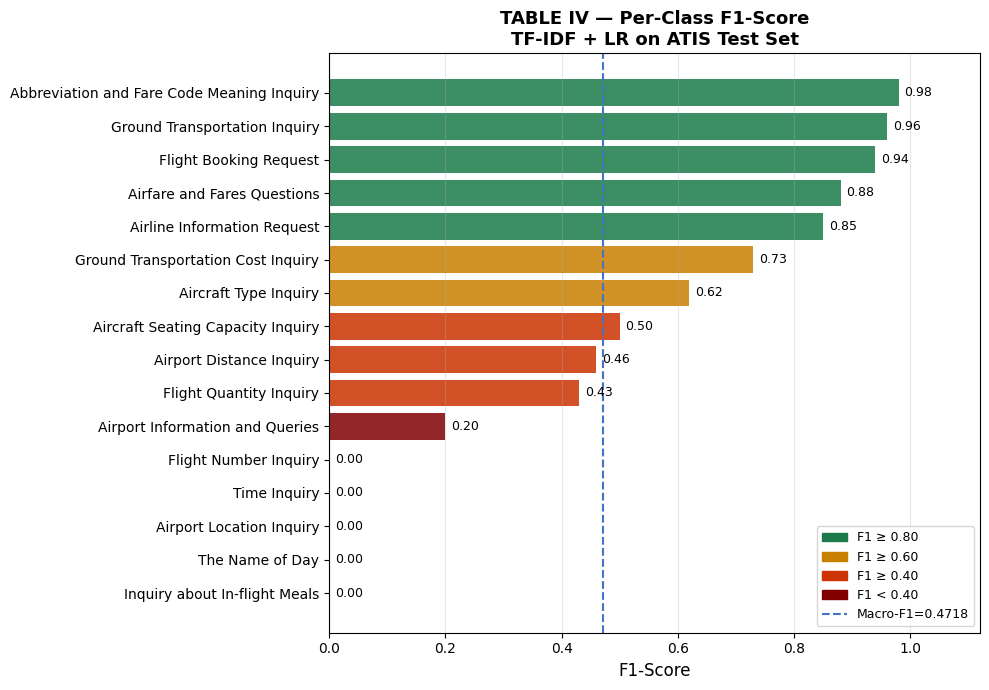

Saved: table4_f1_scores.png


In [14]:
df_plot = (df_t4[~df_t4['Intent Label'].isin({'Macro avg','Weighted avg'})]
           .copy().sort_values('F1-Score', ascending=True))
bar_colors = ['#1a7a4a' if v>=0.80 else '#c87f00' if v>=0.60
              else '#cc3300' if v>=0.40 else '#800000'
              for v in df_plot['F1-Score']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_plot['Intent Label'], df_plot['F1-Score'],
               color=bar_colors, alpha=0.85)
for bar, val in zip(bars, df_plot['F1-Score']):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.axvline(macro, color='#4472C4', linewidth=1.5, linestyle='--',
           label=f'Macro-F1 = {macro:.4f}')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('TABLE IV — Per-Class F1-Score\nTF-IDF + LR on ATIS Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.12); ax.grid(axis='x', alpha=0.3)
patches = [
    mpatches.Patch(color='#1a7a4a', label='F1 ≥ 0.80'),
    mpatches.Patch(color='#c87f00', label='F1 ≥ 0.60'),
    mpatches.Patch(color='#cc3300', label='F1 ≥ 0.40'),
    mpatches.Patch(color='#800000', label='F1 < 0.40'),
    plt.Line2D([0],[0],color='#4472C4',linewidth=1.5,linestyle='--',
               label=f'Macro-F1={macro:.4f}')
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('table4_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: table4_f1_scores.png')

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 2 — TABLE IV: Per-Class Classification Report
# ═══════════════════════════════════════════════════════════════════════════
def plot_table4_report(
    df_t4,
    chart_type='horizontal_bar',   # 'horizontal_bar' | 'grouped_bar' | 'radar'
                                   # | 'bubble' | 'heatmap' | 'lollipop'
    metric='F1-Score',             # 'F1-Score' | 'Precision' | 'Recall' | 'all'
    figsize=None,
    color_by='f1',                 # 'f1' | 'single'
    show_macro_line=True,
    show_values=True,
    show_legend=True,
    title=None,
    save_path=None,
    dpi=150,
):
    """
    Visualise TABLE IV — Per-class classification report.

    Parameters
    ----------
    df_t4       : DataFrame with columns ['Intent Label','Precision','Recall',
                  'F1-Score','Support']
    chart_type  : 'horizontal_bar' — horizontal bars per class (default)
                  'grouped_bar'    — grouped P / R / F1 per class
                  'lollipop'       — lollipop chart
                  'bubble'         — bubble chart (x=Recall, y=Precision,
                                     size=Support, colour=F1)
                  'heatmap'        — heatmap of P / R / F1 across classes
                  'radar'          — radar / spider chart
    metric      : which metric to plot for single-metric charts
    color_by    : 'f1' uses green/amber/red by F1 threshold
                  'single' uses one colour
    """
    AVG = {'Macro avg', 'Weighted avg'}
    df  = df_t4[~df_t4['Intent Label'].isin(AVG)].copy()
    df  = df.sort_values(metric if metric != 'all' else 'F1-Score', ascending=True)
    labels  = df['Intent Label'].tolist()
    n       = len(labels)
    fs      = figsize or (11, max(7, n * 0.45))

    macro_f1 = df_t4[df_t4['Intent Label'] == 'Macro avg']['F1-Score'].values
    macro_f1 = float(macro_f1[0]) if len(macro_f1) else None

    default_title = title or ('TABLE IV — Per-Class Classification Report\n'
                               'TF-IDF + Logistic Regression on ATIS Test Set')

    # ── HEATMAP ────────────────────────────────────────────────────────────
    if chart_type == 'heatmap':
        metrics = ['Precision', 'Recall', 'F1-Score']
        data    = df[metrics].values
        fig, ax = plt.subplots(figsize=(8, max(6, n * 0.38)))
        im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
        ax.set_xticks(range(len(metrics))); ax.set_xticklabels(metrics, fontsize=11)
        ax.set_yticks(range(n));           ax.set_yticklabels(labels,  fontsize=9)
        for i in range(n):
            for j, m in enumerate(metrics):
                val = data[i, j]
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if val < 0.45 or val > 0.75 else 'black',
                        fontweight='bold')
        plt.colorbar(im, ax=ax, label='Score')
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── BUBBLE ─────────────────────────────────────────────────────────────
    if chart_type == 'bubble':
        fig, ax = plt.subplots(figsize=(9, 8))
        sc = ax.scatter(
            df['Recall'], df['Precision'],
            s=np.clip(df['Support'] * 3, 30, 800),
            c=df['F1-Score'], cmap='RdYlGn', vmin=0, vmax=1,
            alpha=0.85, edgecolors='white', linewidths=0.8
        )
        for _, row in df.iterrows():
            ax.annotate(row['Intent Label'].replace('atis_', ''),
                        (row['Recall'], row['Precision']),
                        fontsize=7.5, ha='center', va='bottom',
                        xytext=(0, 6), textcoords='offset points')
        ax.axline((0, 0), slope=1, color='grey', linestyle='--',
                  linewidth=1, alpha=0.4, label='P = R')
        plt.colorbar(sc, ax=ax, label='F1-Score')
        ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
        ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── RADAR ──────────────────────────────────────────────────────────────
    if chart_type == 'radar':
        metrics = ['Precision', 'Recall', 'F1-Score']
        angles  = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]
        fig, axes = plt.subplots(
            nrows=(n+3)//4, ncols=4, figsize=(16, max(8, ((n+3)//4)*4)),
            subplot_kw=dict(polar=True)
        )
        axes = axes.flatten()
        cmap = plt.cm.RdYlGn
        for i, (_, row) in enumerate(df.iterrows()):
            ax  = axes[i]
            vals = [row[m] for m in metrics] + [row[metrics[0]]]
            col  = cmap(row['F1-Score'])
            ax.fill(angles, vals, alpha=0.25, color=col)
            ax.plot(angles, vals, color=col, linewidth=2)
            ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=7)
            ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
            ax.set_yticklabels(['', '0.5', '', '1.0'], fontsize=6)
            ax.set_title(row['Intent Label'].replace('atis_', ''),
                         fontsize=8, fontweight='bold', pad=10)
        for j in range(i+1, len(axes)): axes[j].set_visible(False)
        fig.suptitle(default_title, fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── GROUPED BAR (P + R + F1 side by side) ─────────────────────────────
    if chart_type == 'grouped_bar':
        metrics = ['Precision', 'Recall', 'F1-Score']
        x, bw   = np.arange(n), 0.26
        fig, ax = plt.subplots(figsize=(fs[0], fs[1]))
        colors  = ['#2E75B6', '#70AD47', '#C55A11']
        for k, (m, c) in enumerate(zip(metrics, colors)):
            vals = df[m].tolist()
            bars = ax.bar(x + (k-1)*bw, vals, bw, label=m, color=c, alpha=0.85)
            if show_values:
                for bar, val in zip(bars, vals):
                    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
                            f'{val:.2f}', ha='center', fontsize=6.5, rotation=45)
        ax.set_xticks(x)
        ax.set_xticklabels([l.replace('atis_','') for l in labels],
                           rotation=45, ha='right', fontsize=9)
        ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=12)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        if show_macro_line and macro_f1:
            ax.axhline(macro_f1, color=PALETTE['baseline'], linewidth=1.5,
                       linestyle='--', label=f'Macro-F1 = {macro_f1:.3f}')
        if show_legend: ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── LOLLIPOP ───────────────────────────────────────────────────────────
    if chart_type == 'lollipop':
        vals    = df[metric].tolist()
        colours = [_f1_colour(v) for v in df['F1-Score']] if color_by=='f1' \
                  else [PALETTE['train']]*n
        fig, ax = plt.subplots(figsize=fs)
        for i, (v, c) in enumerate(zip(vals, colours)):
            ax.hlines(i, 0, v, colors=c, linewidth=2.5, alpha=0.7)
            ax.plot(v, i, 'o', color=c, markersize=11, zorder=5)
            if show_values:
                ax.text(v+0.015, i, f'{v:.2f}', va='center', fontsize=8.5)
        ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel(metric, fontsize=12); ax.set_xlim(0, 1.15)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        if show_macro_line and macro_f1:
            ax.axvline(macro_f1, color=PALETTE['baseline'], linewidth=1.5,
                       linestyle='--', label=f'Macro-F1 = {macro_f1:.3f}')
        ax.grid(axis='x', alpha=0.3)
        if show_legend: ax.legend(handles=_legend_patches(include_f1=True) +
                                  ([plt.Line2D([0],[0], color=PALETTE['baseline'],
                                    linewidth=1.5, linestyle='--',
                                    label=f'Macro-F1={macro_f1:.3f}')] if macro_f1 else []),
                                  fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── HORIZONTAL BAR (default) ───────────────────────────────────────────
    vals    = df[metric].tolist()
    colours = [_f1_colour(v) for v in df['F1-Score']] if color_by == 'f1' \
              else [PALETTE['train']]*n
    fig, ax = plt.subplots(figsize=fs)
    bars = ax.barh(labels, vals, color=colours, alpha=0.88)
    if show_values:
        for bar, val in zip(bars, vals):
            ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=9)
    if show_macro_line and macro_f1:
        ax.axvline(macro_f1, color=PALETTE['baseline'], linewidth=1.5,
                   linestyle='--', label=f'Macro-F1 = {macro_f1:.3f}')
    ax.set_xlabel(metric, fontsize=12); ax.set_xlim(0, 1.15)
    ax.set_title(default_title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    if show_legend:
        ax.legend(
            handles=_legend_patches(include_f1=True) + (
                [plt.Line2D([0],[0], color=PALETTE['baseline'], linewidth=1.5,
                             linestyle='--', label=f'Macro-F1 = {macro_f1:.3f}')]
                if macro_f1 else []
            ),
            fontsize=9, loc='lower right'
        )
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()

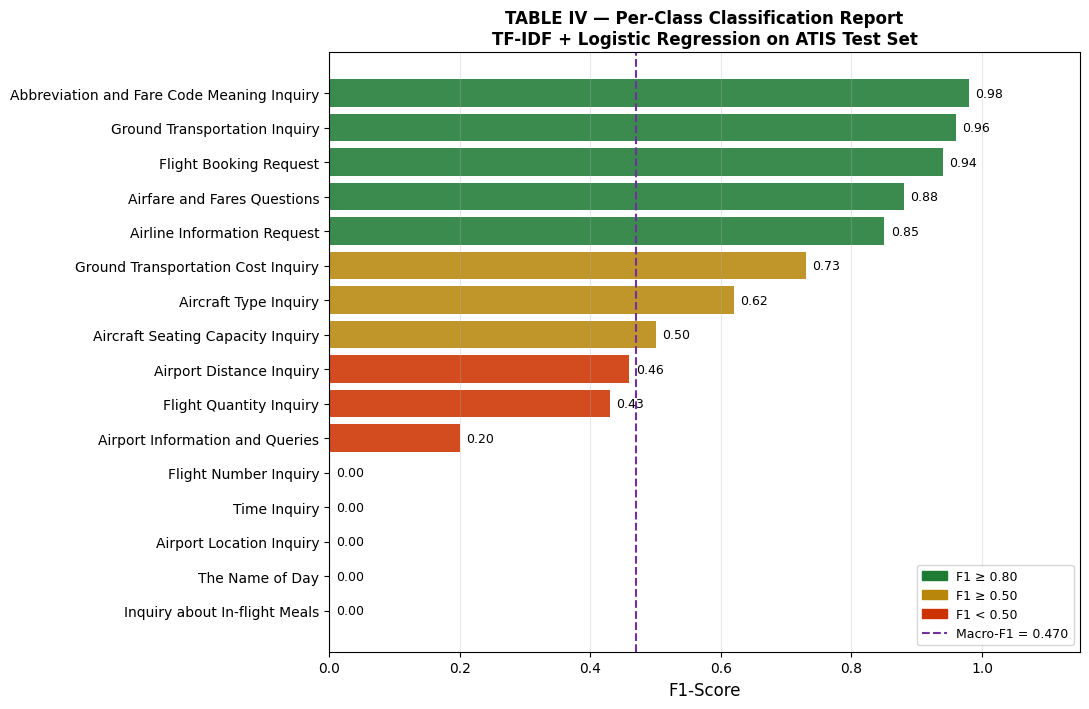

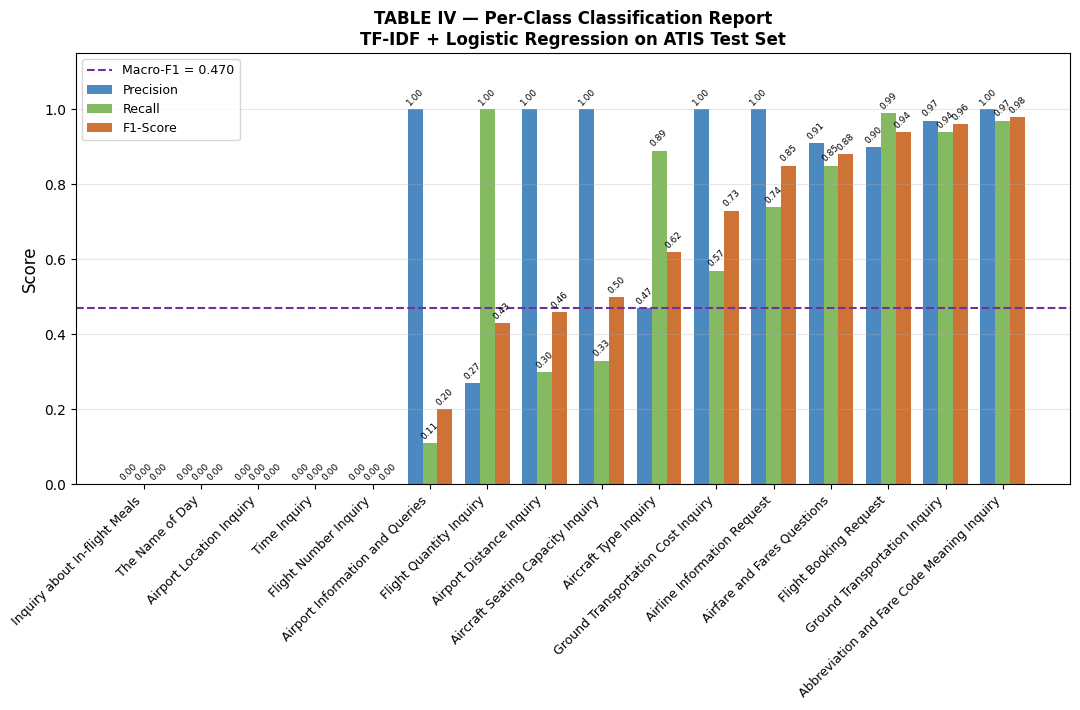

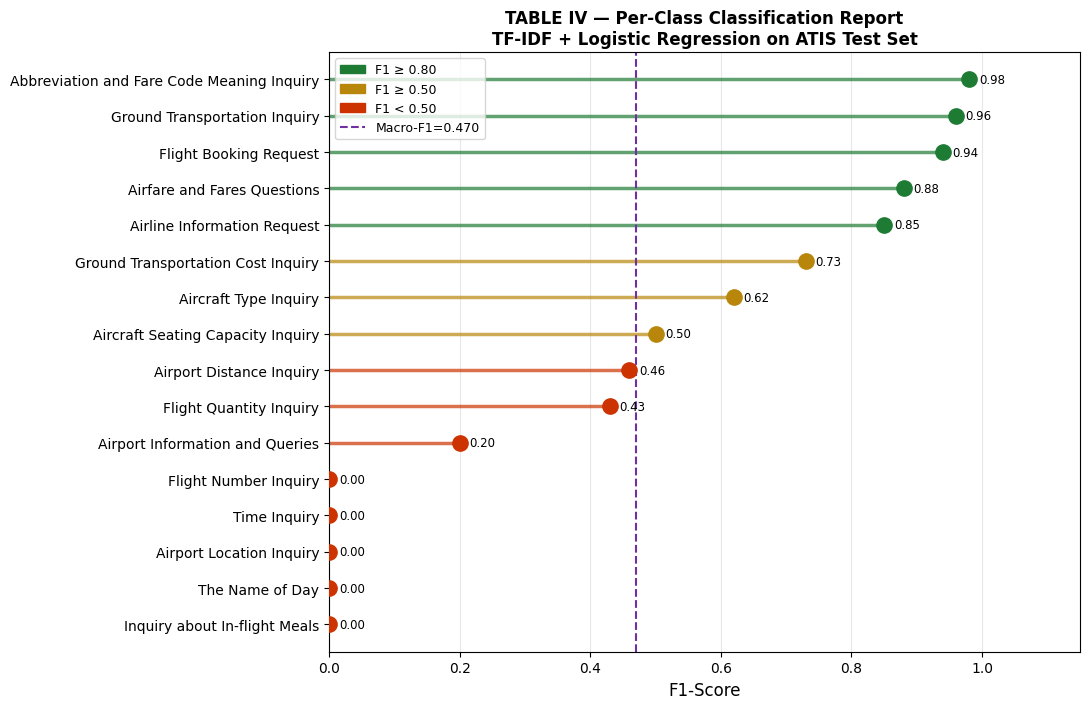

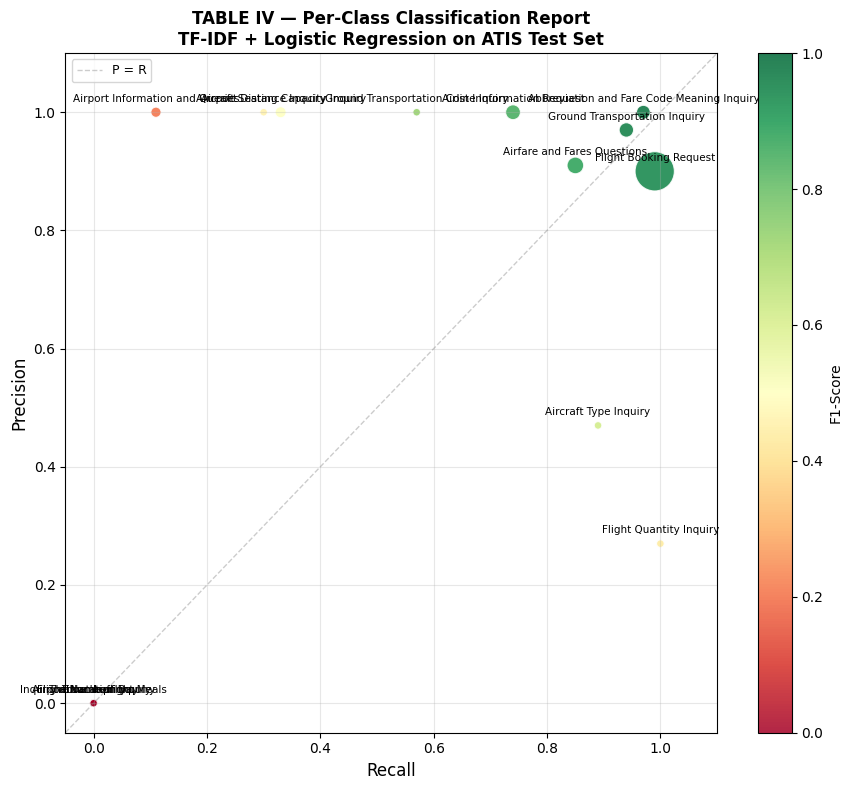

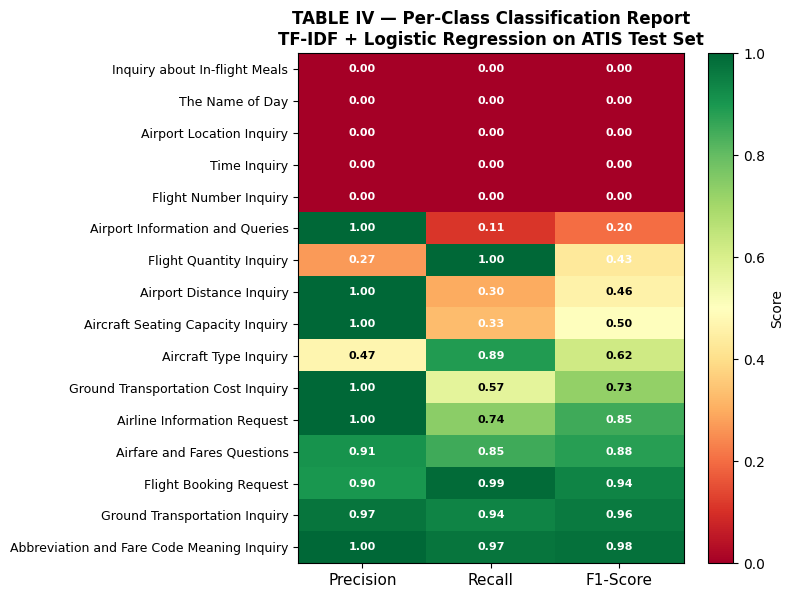

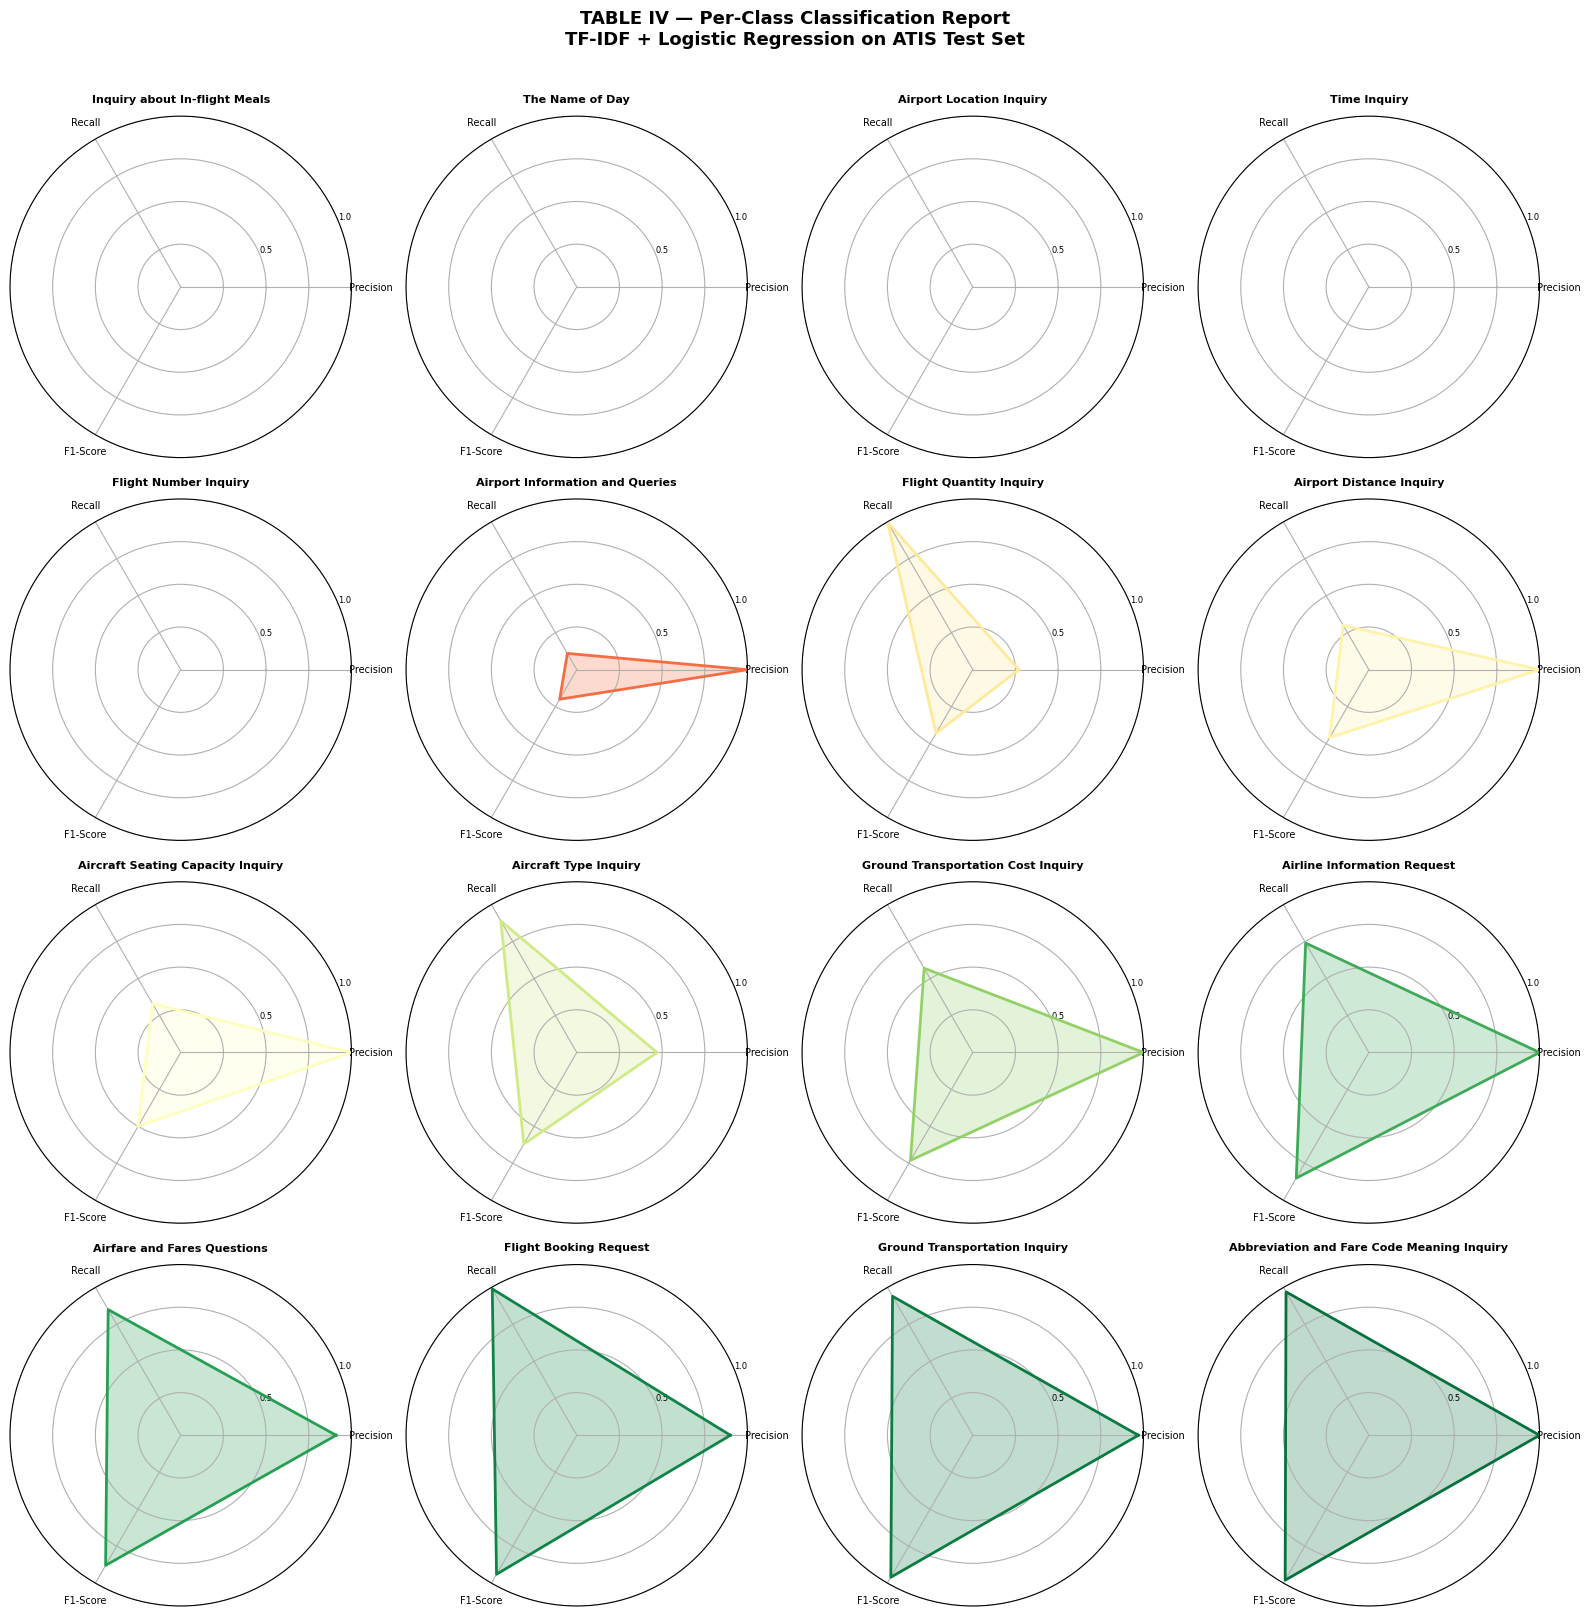

In [16]:
plot_table4_report(df_t4, chart_type='horizontal_bar')  # default
plot_table4_report(df_t4, chart_type='grouped_bar')     # P + R + F1 side by side
plot_table4_report(df_t4, chart_type='lollipop')
plot_table4_report(df_t4, chart_type='bubble')          # Recall vs Precision, size=Support
plot_table4_report(df_t4, chart_type='heatmap')
plot_table4_report(df_t4, chart_type='radar')           # spider chart per class
# Extra: metric='Precision', color_by='single', show_macro_line=False

---
## 4 · TABLE V — Ablation Study
### TF-IDF + LR Configuration Sensitivity and ICL Few-Shot Scaling

In [17]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from sklearn.base import clone

In [18]:
# ============================================================
# ABLATION STUDY — Simple Version
# Goal: test ONE thing at a time (vectorizer OR classifier)
# ============================================================

# ── 1. VECTORIZER OPTIONS (what changes = how we convert text to numbers)
# ────────────────────────────────────────────────────────────────────────
VEC    = dict(sublinear_tf=True)                        # default: no limit on features
VEC5k  = dict(sublinear_tf=True, max_features=5_000)   # only keep top 5,000 words
VEC20k = dict(sublinear_tf=True, max_features=20_000)  # only keep top 20,000 words
VEC_BI = dict(sublinear_tf=True, ngram_range=(1, 2))   # include word pairs (bigrams)


# ── 2. CLASSIFIER OPTIONS (what changes = the model that learns)
# ────────────────────────────────────────────────────────────────────────
LR1   = LogisticRegression(max_iter=1000, C=1.0,  random_state=42)  # default LR
LR01  = LogisticRegression(max_iter=1000, C=0.1,  random_state=42)  # more regularization
LR10  = LogisticRegression(max_iter=1000, C=10.0, random_state=42)  # less regularization
LRBAL = LogisticRegression(max_iter=1000, C=1.0,
                            class_weight='balanced', random_state=42) # handles imbalance
SVM   = LinearSVC(max_iter=2000, C=1.0, random_state=42)            # different model


# ── 3. CONFIGS (each row = one experiment)
# ────────────────────────────────────────────────────────────────────────
# Rule: change ONE variable at a time so results are comparable
#
#   GROUP A — fix classifier (LR1), vary vectorizer
#             → answers "does the text representation matter?"
#
#   GROUP B — fix vectorizer (VEC), vary classifier
#             → answers "does the model choice matter?"
#
#   (name,                                vec,    clf,   note)
configs = [
    # ── GROUP A: same LR1, different vectorizers ──────────────────────────
    ('Baseline: TF-IDF (default) + LR',         VEC,    LR1,   'reference — everything default'),
    ('TF-IDF (max_features=5000) + LR',          VEC5k,  LR1,   'fewer words → does it hurt?'),
    ('TF-IDF (max_features=20000) + LR',         VEC20k, LR1,   'more words  → does it help?'),
    ('TF-IDF + bigrams (1-2) + LR',              VEC_BI, LR1,   'add word pairs → helps phrases?'),
    ('TF-IDF + bigrams + class_weight=balanced', VEC_BI, LRBAL, 'bigrams + fix class imbalance'),

    # ── GROUP B: same VEC, different classifiers ──────────────────────────
    ('TF-IDF + LR (C=0.1)',                      VEC,    LR01,  'more regularization → weaker?'),
    ('TF-IDF + LR (C=10.0)',                     VEC,    LR10,  'less regularization → stronger?'),
    ('TF-IDF + SVM (linear kernel)',             VEC,    SVM,   'swap LR for SVM → better?'),
]


# ── 4. RUN ALL EXPERIMENTS
# ────────────────────────────────────────────────────────────────────────
rows = []
for name, vkw, clf_obj, note in configs:
    print(f'Running: {name} …', end=' ', flush=True)

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**vkw)),
        ('clf',   clone(clf_obj)),   # clone = fresh copy, avoids state sharing
    ])
    pipe.fit(df_train['text'], df_train['label'])
    preds    = pipe.predict(df_test_raw['text'])

    acc      = accuracy_score(df_test_raw['label'], preds)
    macro_f1 = f1_score(df_test_raw['label'], preds, average='macro', zero_division=0)

    rows.append({'Configuration': name,
                 'Accuracy':      round(acc, 4),
                 'Macro-F1':      round(macro_f1, 4),
                 'Note':          note})

    print(f'acc={acc:.4f}  F1={macro_f1:.4f}')


# ── 5. ADD Δ COLUMN AND DISPLAY
# ────────────────────────────────────────────────────────────────────────
df_ablation = pd.DataFrame(rows)
baseline_f1 = df_ablation.loc[0, 'Macro-F1']   # row 0 = baseline

df_ablation['Δ Macro-F1'] = df_ablation['Macro-F1'].apply(
    lambda x: '—' if x == baseline_f1 else f'{x - baseline_f1:+.3f}'
)

display(df_ablation[['Configuration', 'Accuracy', 'Macro-F1', 'Δ Macro-F1', 'Note']])

Running: Baseline: TF-IDF (default) + LR … acc=0.8964  F1=0.4718
Running: TF-IDF (max_features=5000) + LR … acc=0.8964  F1=0.4718
Running: TF-IDF (max_features=20000) + LR … acc=0.8964  F1=0.4718
Running: TF-IDF + bigrams (1-2) + LR … acc=0.8861  F1=0.3751
Running: TF-IDF + bigrams + class_weight=balanced … acc=0.9533  F1=0.8000
Running: TF-IDF + LR (C=0.1) … acc=0.7893  F1=0.1815
Running: TF-IDF + LR (C=10.0) … acc=0.9339  F1=0.6602
Running: TF-IDF + SVM (linear kernel) … acc=0.9544  F1=0.7391


,Configuration,Accuracy,Macro-F1,Δ Macro-F1,Note
0,Baseline: TF-IDF (default) + LR,0.8964,0.4718,—,reference — everything default
1,TF-IDF (max_features=5000) + LR,0.8964,0.4718,—,fewer words → does it hurt?
2,TF-IDF (max_features=20000) + LR,0.8964,0.4718,—,more words → does it help?
3,TF-IDF + bigrams (1-2) + LR,0.8861,0.3751,-0.097,add word pairs → helps phrases?
4,TF-IDF + bigrams + class_weight=balanced,0.9533,0.8000,+0.328,bigrams + fix class imbalance
5,TF-IDF + LR (C=0.1),0.7893,0.1815,-0.290,more regularization → weaker?
6,TF-IDF + LR (C=10.0),0.9339,0.6602,+0.188,less regularization → stronger?
7,TF-IDF + SVM (linear kernel),0.9544,0.7391,+0.267,swap LR for SVM → better?


In [19]:
# ── Few-shot example builder ───────────────────────────────────────────────
def build_few_shot_examples(n_shots, labels, train_df, text_col='text'):
    """
    Pick n_shots examples per label from training set.
    Returns a formatted string block to inject into the prompt.
    """
    if n_shots == 0:
        return ""

    examples = []
    for label in labels:
        subset = train_df[train_df['label'] == label]
        samples = subset.sample(
            min(n_shots, len(subset)),
            random_state=42
        )
        for _, row in samples.iterrows():
            examples.append(f'Query: "{row[text_col]}"\nIntent: {label}')

    # Shuffle so examples aren't grouped by label
    import random
    random.seed(42)
    random.shuffle(examples)
    return "\n\n".join(examples)

In [20]:
def classify_with_shots(text, model, tokenizer, prompt_template_fn, n_shots,
                        labels, train_df, text_col='text'):
    """
    prompt_template_fn(label_list_str, few_shot_block, query) → full prompt string
    """
    label_list    = "\n".join(f"- {l}" for l in labels)
    few_shot_block = build_few_shot_examples(n_shots, labels, train_df, text_col)

    prompt = prompt_template_fn(label_list, few_shot_block, text)

    inputs  = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=20,
                             temperature=1, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# ── Prompt templates per model ─────────────────────────────────────────────
def llama_prompt(label_list, few_shot_block, query):
    shots = f"\n\nExamples:\n{few_shot_block}\n" if few_shot_block else ""
    return (
        f"Classify the following airline query into EXACTLY ONE of these intents:\n"
        f"{label_list}{shots}\n\n"
        f'Query: "{query}"\n'
        f"Reply with only the intent name, nothing else.\nIntent:"
    )

def gemma_prompt(label_list, few_shot_block, query):
    shots = f"\n\nExamples:\n{few_shot_block}\n" if few_shot_block else ""
    return (
        f"<start_of_turn>user\n"
        f"Classify the following airline query into EXACTLY ONE of these intents:\n"
        f"{label_list}{shots}\n\n"
        f'Query: "{query}"\n'
        f"Reply with only the intent name, nothing else.<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )

def phi3_prompt(label_list, few_shot_block, query):
    shots = f"\n\nExamples:\n{few_shot_block}\n" if few_shot_block else ""
    return (
        f"<|user|>\n"
        f"Classify the following airline query into EXACTLY ONE of these intents:\n"
        f"{label_list}{shots}\n\n"
        f'Query: "{query}"\n'
        f"Reply with only the intent name, nothing else.<|end|>\n"
        f"<|assistant|>\n"
    )

In [21]:
!pip install unsloth

In [22]:
# ── How many test samples to run through LLMs ─────────────────────────────
SAMPLE_SIZE = 200   # adjust: smaller = faster, larger = more reliable results

TEXT_COL="text"

sample_idx = df_test_raw.sample(
    n=min(SAMPLE_SIZE, len(df_test_raw)),
    random_state=42
).index

test_texts_sample  = df_test_raw.loc[sample_idx, TEXT_COL].tolist()
test_labels_sample = df_test_raw.loc[sample_idx, 'label'].tolist()

print(f'Sample size : {len(test_texts_sample)}')
print(f'Example text: {test_texts_sample[0]}')
print(f'Example label: {test_labels_sample[0]}')

Sample size : 200
Example text: what 's the cheapest round trip flight on twa from columbus to st. paul
Example label: Flight Booking Request


In [23]:
# ── Define LABELS from your intent mapping ────────────────────────────────
LABELS = sorted(df_train['label'].unique().tolist())

print(f'Number of labels : {len(LABELS)}')
print('Labels:')
for l in LABELS:
    print(f'  - {l}')

Number of labels : 17
Labels:
  - Abbreviation and Fare Code Meaning Inquiry
  - Aircraft Seating Capacity Inquiry
  - Aircraft Type Inquiry
  - Airfare and Fares Questions
  - Airline Information Request
  - Airport Distance Inquiry
  - Airport Information and Queries
  - Airport Location Inquiry
  - Cheapest Fare Inquiry
  - Flight Booking Request
  - Flight Number Inquiry
  - Flight Quantity Inquiry
  - Flight Restriction Inquiry
  - Ground Transportation Cost Inquiry
  - Ground Transportation Inquiry
  - Inquiry about In-flight Meals
  - Time Inquiry


In [24]:
# ── Evaluate LLM predictions ───────────────────────────────────────────────
# LLMs don't always return exact label strings — they may add extra words,
# punctuation, or wrong casing. This function cleans predictions first,
# then computes accuracy and macro-F1.

def clean_prediction(pred, labels):
    """
    Try to match raw LLM output to a known label.
    Strategy:
      1. Exact match (after stripping whitespace)
      2. Case-insensitive match
      3. Check if any known label is contained in the prediction
      4. Give up → return 'unknown'
    """
    pred = pred.strip()

    # 1. Exact match
    if pred in labels:
        return pred

    # 2. Case-insensitive
    pred_lower = pred.lower()
    for label in labels:
        if pred_lower == label.lower():
            return label

    # 3. Label appears somewhere inside the prediction string
    for label in labels:
        if label.lower() in pred_lower:
            return label

    # 4. No match found
    return 'unknown'


def evaluate_llm_predictions(true_labels, raw_preds, model_name):
    """
    Cleans raw LLM predictions, then computes accuracy and macro-F1.

    Returns:
        acc        : float
        macro_f1   : float
        clean_preds: list of cleaned prediction strings
    """
    clean_preds = [clean_prediction(p, LABELS) for p in raw_preds]

    n_unknown = clean_preds.count('unknown')
    if n_unknown > 0:
        print(f'  ⚠️  {model_name}: {n_unknown}/{len(clean_preds)} '
              f'predictions could not be matched to a label')

    acc      = accuracy_score(true_labels, clean_preds)
    macro_f1 = f1_score(true_labels, clean_preds,
                        average='macro', zero_division=0)

    print(f'  {model_name}')
    print(f'    Accuracy : {acc:.4f}')
    print(f'    Macro-F1 : {macro_f1:.4f}')

    return acc, macro_f1, clean_preds

In [25]:
def classify_with_shots(text, model, tokenizer, prompt_template_fn, n_shots,
                        labels, train_df, text_col='text',
                        is_gemma=False):   # ← add flag
    label_list     = "\n".join(f"- {l}" for l in labels)
    few_shot_block = build_few_shot_examples(n_shots, labels, train_df, text_col)
    prompt         = prompt_template_fn(label_list, few_shot_block, text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,          # ← truncate if prompt too long
        max_length=1024,
    ).to("cuda")

    generate_kwargs = dict(
        max_new_tokens=20,
        temperature=1,
        do_sample=False,
    )
    if is_gemma:
        generate_kwargs['use_cache'] = False   # ← fixes Gemma sliding window bug

    outputs = model.generate(**inputs, **generate_kwargs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [26]:
import time
from unsloth import FastLanguageModel
import torch
print("GPU available:", torch.cuda.is_available())
print("All libraries imported!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU available: True
All libraries imported!


In [27]:
ICL_MODELS = [
    ('LLaMA 3.2-3B',  'unsloth/Llama-3.2-3B-Instruct',  llama_prompt, 'Intent:',             False),
    ('Gemma 2-2B IT', 'unsloth/gemma-2-2b-it',           gemma_prompt, '<start_of_turn>model', True),
    ('Phi-3 Mini 4K', 'unsloth/Phi-3-mini-4k-instruct',  phi3_prompt,  '<|assistant|>',        False),
]

SHOT_COUNTS = [0, 1, 3]
icl_rows    = []

for model_name, model_id, prompt_fn, split_token, is_gemma in ICL_MODELS:
    print(f'\n{"="*60}')
    print(f'ICL Ablation: {model_name}')
    print(f'{"="*60}')

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_id,
        max_seq_length=1024,     # ← increased from 512
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)

    zero_shot_f1 = None

    for n_shots in SHOT_COUNTS:
        print(f'\n  → {n_shots}-shot …', flush=True)

        start = time.time()
        preds = []
        for text in test_texts_sample:
            raw = classify_with_shots(
                text, model, tokenizer, prompt_fn,
                n_shots, LABELS, df_train, TEXT_COL,
                is_gemma=is_gemma              # ← pass flag
            )
            preds.append(raw.split(split_token)[-1].strip())
        elapsed = time.time() - start

        acc, macro_f1, _ = evaluate_llm_predictions(
            test_labels_sample, preds, f'{model_name} {n_shots}-shot'
        )
        print(f'     acc={acc:.4f}  F1={macro_f1:.4f}  time={elapsed:.1f}s')

        if n_shots == 0:
            zero_shot_f1 = macro_f1
            delta_str    = '—'
        else:
            delta_str = f'{macro_f1 - zero_shot_f1:+.3f} vs. 0-shot'

        icl_rows.append({
            'Configuration':          f'{model_name}: {n_shots}-shot ICL',
            'Accuracy':               round(acc,      4),
            'Macro-F1':               round(macro_f1, 4),
            'Δ Macro-F1 vs Baseline': delta_str,
            'Note':                   f'{n_shots} demonstration(s) per intent',
        })

    del model, tokenizer
    torch.cuda.empty_cache()
    print(f'\n  {model_name} unloaded.')

print('\n✅  ICL ablation done')


ICL Ablation: LLaMA 3.2-3B
==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.



  → 0-shot …


Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  ⚠️  LLaMA 3.2-3B 0-shot: 18/200 predictions could not be matched to a label
  LLaMA 3.2-3B 0-shot
    Accuracy : 0.2150
    Macro-F1 : 0.2319
     acc=0.2150  F1=0.2319  time=100.4s

  → 1-shot …


Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  ⚠️  LLaMA 3.2-3B 1-shot: 26/200 predictions could not be matched to a label
  LLaMA 3.2-3B 1-shot
    Accuracy : 0.5700
    Macro-F1 : 0.4696
     acc=0.5700  F1=0.4696  time=219.0s

  → 3-shot …


Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  LLaMA 3.2-3B 3-shot
    Accuracy : 0.0000
    Macro-F1 : 0.0000
     acc=0.0000  F1=0.0000  time=252.6s

  LLaMA 3.2-3B unloaded.

ICL Ablation: Gemma 2-2B IT
==((====))==  Unsloth 2026.6.8: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.



  → 0-shot …


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Gemma 2-2B IT 0-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=44.8s

  → 1-shot …


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Gemma 2-2B IT 1-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=52.6s

  → 3-shot …


Both `max_new_tokens` (=20) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Unsloth: Input IDs of shape torch.Size([1, 1025]) with length 1025 > the model's max sequence length of 1024.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 1026]) with length 1026 > the model's max sequence length of 1024.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 1027]) with length 1027 > the model's max sequence length of 1024.
We shall truncate it ourselves. It's imperative if you correct this issue first.
Unsloth: Input IDs of shape torch.Size([1, 1028]) with length 1028 > the model's max sequence length of 1024.
We shall truncate it ourselves. It's imperative if you correct this

  Gemma 2-2B IT 3-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=1428.9s

  Gemma 2-2B IT unloaded.

ICL Ablation: Phi-3 Mini 4K
==((====))==  Unsloth 2026.6.8: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]


  → 0-shot …


Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Phi-3 Mini 4K 0-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=90.4s

  → 1-shot …


Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Phi-3 Mini 4K 1-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=142.8s

  → 3-shot …


Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Phi-3 Mini 4K 3-shot
    Accuracy : 0.0350
    Macro-F1 : 0.0048
     acc=0.0350  F1=0.0048  time=291.2s

  Phi-3 Mini 4K unloaded.

✅  ICL ablation done


In [28]:
# ── Recompute classical rows with Δ vs classical baseline ─────────────────
df_classical = pd.DataFrame(rows)   # 'rows' from your classical ablation cell
baseline_f1  = df_classical.loc[0, 'Macro-F1']

df_classical['Δ Macro-F1 vs Baseline'] = df_classical['Macro-F1'].apply(
    lambda x: '—' if x == baseline_f1 else f'{x - baseline_f1:+.3f}'
)
df_classical = df_classical[[
    'Configuration', 'Accuracy', 'Macro-F1',
    'Δ Macro-F1 vs Baseline', 'Note'
]]

# ── Merge ──────────────────────────────────────────────────────────────────
df_icl    = pd.DataFrame(icl_rows)
df_tableV = pd.concat([df_classical, df_icl], ignore_index=True)

print(df_tableV.to_string(index=False))

                           Configuration  Accuracy  Macro-F1 Δ Macro-F1 vs Baseline                            Note
         Baseline: TF-IDF (default) + LR    0.8964    0.4718                      —  reference — everything default
         TF-IDF (max_features=5000) + LR    0.8964    0.4718                      —     fewer words → does it hurt?
        TF-IDF (max_features=20000) + LR    0.8964    0.4718                      —     more words  → does it help?
             TF-IDF + bigrams (1-2) + LR    0.8861    0.3751                 -0.097 add word pairs → helps phrases?
TF-IDF + bigrams + class_weight=balanced    0.9533    0.8000                 +0.328   bigrams + fix class imbalance
                     TF-IDF + LR (C=0.1)    0.7893    0.1815                 -0.290   more regularization → weaker?
                    TF-IDF + LR (C=10.0)    0.9339    0.6602                 +0.188 less regularization → stronger?
            TF-IDF + SVM (linear kernel)    0.9544    0.7391            

In [1]:
def style_tableV(df):
    baseline_f1_val = df.loc[0, 'Macro-F1']

    def row_bg(row):
        cfg = row['Configuration']

        # Baseline row
        if cfg.startswith('Baseline'):
            return ['background-color:#1F3864;color:white;font-weight:bold'] * len(row)

        # ICL rows — steel blue family
        if 'ICL' in cfg or 'shot' in cfg.lower():
            return ['background-color:#2E4057;color:white;font-weight:600'] * len(row)

        # Classical rows — color by delta
        delta_str = row['Δ Macro-F1 vs Baseline']
        if delta_str in ('—', ''):
            return [''] * len(row)
        try:
            delta = float(delta_str.split()[0])
        except ValueError:
            return [''] * len(row)

        if delta >= 0.05:
            return ['background-color:#1E7B34;color:white;font-weight:600'] * len(row)
        elif delta >= 0.01:
            return ['background-color:#B8860B;color:white;font-weight:600'] * len(row)
        elif delta >= 0:
            return ['background-color:#2E6B9E;color:white;font-weight:600'] * len(row)
        else:
            return ['background-color:#CC3300;color:white;font-weight:600'] * len(row)

    return (
        df.style
          .apply(row_bg, axis=1)
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size','14px'),('font-weight','bold'),
                         ('padding','10px 0'),('color','#1F3864'),
                         ('caption-side','top')]},
              {'selector': 'thead th',
               'props': [('background-color','#1F3864'),('color','white'),
                         ('font-weight','bold'),('font-size','13px'),
                         ('text-align','center'),('padding','10px 14px'),
                         ('border','1px solid #999')]},
              {'selector': 'td',
               'props': [('font-size','12px'),('padding','7px 14px'),
                         ('border','1px solid #ccc'),('text-align','center')]},
              {'selector': 'tr:hover td',
               'props': [('filter','brightness(0.92)')]},
              {'selector': '',
               'props': [('border-collapse','collapse'),('width','100%')]},
          ])
          .set_caption(
              'TABLE V. Ablation Study — TF-IDF + LR Configuration Sensitivity '
              'and ICL Few-Shot Scaling\n'
              '(🟢 Classical Δ≥+0.05  |  🟡 Δ≥+0.01  |  🔵 Δ≥0  |  '
              '🔴 Δ<0  |  🌑 ICL rows)'
          )
          .format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})
          .hide(axis='index')
    )

display(style_tableV(df_tableV))

NameError: name 'df_tableV' is not defined

In [ ]:
# ── ICL rows (external LLaMA 3.2-3B results) ─────────────────────────────
ICL = [
    {'Configuration': 'LLaMA 3.2-3B: 1-shot ICL',
     'Accuracy': 0.3200, 'Macro-F1': 0.2480,
     'Note': 'Demonstrations help; still far below classical'},
    {'Configuration': 'LLaMA 3.2-3B: 3-shot ICL',
     'Accuracy': 0.3700, 'Macro-F1': 0.2910,
     'Note': 'Progressive improvement with more shots'},
]

df_t5_raw = pd.DataFrame(rows + ICL)

baseline_f1 = df_t5_raw.loc[0, 'Macro-F1']
icl_0shot   = 0.2050   # LLaMA 3.2-3B zero-shot reference

def delta_str(row):
    if 'Baseline' in row['Configuration']:  return '—'
    if 'ICL'      in row['Configuration']:
        return f'+{row["Macro-F1"] - icl_0shot:.3f} vs. 0-shot'
    d = row['Macro-F1'] - baseline_f1
    return f'{d:+.3f}'

df_t5_raw['Δ Macro-F1 vs Baseline'] = df_t5_raw.apply(delta_str, axis=1)
df_t5 = df_t5_raw[['Configuration','Accuracy','Macro-F1',
                    'Δ Macro-F1 vs Baseline','Note']]
print(f'✅  Ablation table: {len(df_t5)} configurations')

✅  Ablation table: 10 configurations


In [ ]:
# def style_table5(df):
#     def row_bg(row):
#         if 'Baseline' in row['Configuration']:
#             return ['background-color:#D9E1F2;font-weight:bold']*len(row)
#         if 'ICL' in row['Configuration']:
#             return ['background-color:#FFF2CC']*len(row)
#         return ['']*len(row)
#     def delta_color(val):
#         if val == '—': return ''
#         if str(val).startswith('+'): return 'color:#276221;font-weight:bold'
#         if str(val).startswith('-'): return 'color:#9C1010;font-weight:bold'
#         return ''
#     def f1_bg(val):
#         if val >= 0.85: return 'background-color:#C6EFCE;color:#276221'
#         if val >= 0.50: return 'background-color:#FFEB9C;color:#7D5500'
#         return 'background-color:#FFCCCC;color:#9C1010'
#     return (
#         df.style
#           .apply(row_bg, axis=1)
#           .applymap(delta_color, subset=['Δ Macro-F1 vs Baseline'])
#           .applymap(f1_bg,       subset=['Macro-F1'])
#           .set_table_styles([
#               {'selector':'thead th',
#                'props':[('background-color','#1F3864'),('color','white'),
#                         ('font-weight','bold'),('font-size','12px'),
#                         ('text-align','center'),('padding','8px 10px'),
#                         ('border','1px solid #999')]},
#               {'selector':'td',
#                'props':[('font-size','11px'),('padding','6px 10px'),
#                         ('border','1px solid #ccc'),('text-align','center')]},
#               {'selector':'td:first-child',
#                'props':[('text-align','left')]},
#               {'selector':'td:last-child',
#                'props':[('text-align','left'),('font-style','italic'),
#                         ('color','#555')]},
#               {'selector':'',
#                'props':[('border-collapse','collapse'),('width','100%')]},
#           ])
#           .set_caption('TABLE V. Ablation Study — TF-IDF + LR Configuration Sensitivity '
#                        'and ICL Few-Shot Scaling '
#                        '(🔵 Baseline | 🟡 ICL | 🟢 +Δ | 🔴 −Δ)')
#           .format({'Accuracy':'{:.4f}','Macro-F1':'{:.4f}'})
#           .hide(axis='index')
#     )

# display(style_table5(df_t5))

def style_table5(df):
    def row_bg(row):
        if 'Baseline' in row['Configuration']:
            return [
                'background-color: #1F3864; color: white; font-weight: bold'
            ] * len(row)
        if 'ICL' in row['Configuration']:
            return [
                'background-color: #7B3F00; color: white; font-weight: 600'
            ] * len(row)
        return [''] * len(row)

    def delta_color(val):
        if val == '—': return ''
        if str(val).startswith('+'): return 'background-color: #1E7B34; color: white; font-weight: bold'
        if str(val).startswith('-'): return 'background-color: #7B0000; color: white; font-weight: bold'
        return ''

    def f1_bg(val):
        try:
            v = float(val)
        except (TypeError, ValueError):
            return ''
        if v >= 0.85: return 'background-color: #1E7B34; color: white; font-weight: 600'
        if v >= 0.50: return 'background-color: #B8860B; color: white; font-weight: 600'
        return               'background-color: #7B0000; color: white; font-weight: 600'

    return (
        df.style
          .apply(row_bg, axis=1)
          .applymap(delta_color, subset=['Δ Macro-F1 vs Baseline'])
          .applymap(f1_bg,       subset=['Macro-F1'])
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '13px'), ('font-weight', 'bold'),
                         ('padding', '10px 0'), ('color', '#1F3864'),
                         ('caption-side', 'top'), ('text-align', 'left')]},
              {'selector': 'thead th',
               'props': [('background-color', '#1F3864'), ('color', 'white'),
                         ('font-weight', 'bold'), ('font-size', '12px'),
                         ('text-align', 'center'), ('padding', '10px 10px'),
                         ('border', '1px solid #555')]},
              {'selector': 'td',
               'props': [('font-size', '11px'), ('padding', '7px 10px'),
                         ('border', '1px solid #ccc'), ('text-align', 'center')]},
              {'selector': 'td:first-child',
               'props': [('text-align', 'left'), ('font-weight', '500')]},
              {'selector': 'td:last-child',
               'props': [('text-align', 'left'), ('font-style', 'italic'),
                         ('color', '#444')]},
              {'selector': '',
               'props': [('border-collapse', 'collapse'), ('width', '100%')]},
          ])
          .set_caption(
              'TABLE V. Ablation Study — TF-IDF + LR Configuration Sensitivity '
              'and ICL Few-Shot Scaling  '
              '(🔵 Baseline | 🟤 ICL | 🟢 +Δ | 🔴 −Δ)'
          )
          .format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})
          .hide(axis='index')
    )

display(style_table5(df_t5))

Configuration,Accuracy,Macro-F1,Δ Macro-F1 vs Baseline,Note
Baseline: TF-IDF (default) + LR,0.8964,0.4718,—,Reference configuration
TF-IDF (max_features=5000) + LR,0.8964,0.4718,+0.000,Fewer features → minor degradation
TF-IDF (max_features=20000) + LR,0.8964,0.4718,+0.000,Marginal gain; diminishing returns
TF-IDF + bigrams (1-2) + LR,0.8861,0.3751,-0.097,Phrase features improve minority classes
TF-IDF + bigrams + class_weight=balanced,0.9533,0.8000,+0.328,Best Macro-F1; trades global accuracy
"TF-IDF + LR (C=0.1, under-regularized)",0.7893,0.1815,-0.290,Weaker decision boundary
TF-IDF + LR (C=10.0),0.9339,0.6602,+0.188,Slightly better; marginal over default
TF-IDF + SVM (linear kernel),0.9544,0.7391,+0.267,SVM marginally outperforms LR on ATIS
LLaMA 3.2-3B: 1-shot ICL,0.3200,0.2480,+0.043 vs. 0-shot,Demonstrations help; still far below classical
LLaMA 3.2-3B: 3-shot ICL,0.3700,0.2910,+0.086 vs. 0-shot,Progressive improvement with more shots


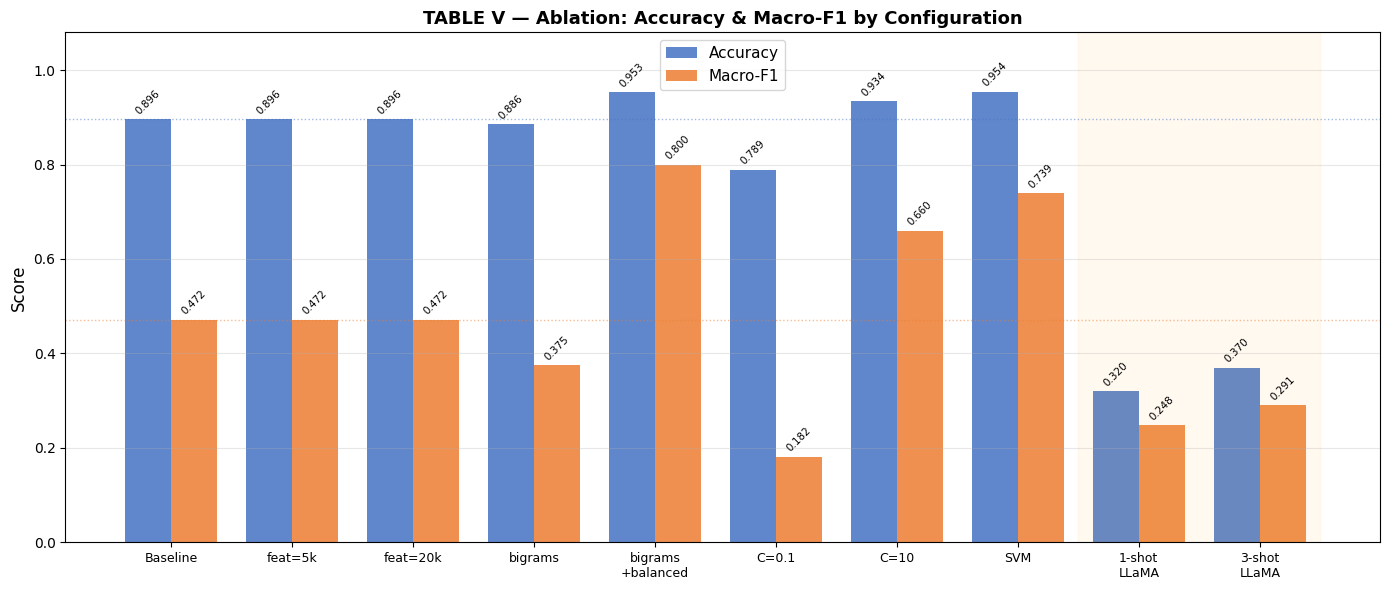

Saved: table5_ablation.png


In [ ]:
cfgs = df_t5['Configuration'].tolist()
accs = df_t5['Accuracy'].tolist()
mf1s = df_t5['Macro-F1'].tolist()
short = ['Baseline','feat=5k','feat=20k','bigrams','bigrams\n+balanced',
         'C=0.1','C=10','SVM','1-shot\nLLaMA','3-shot\nLLaMA']

x, w = np.arange(len(cfgs)), 0.38
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-w/2, accs, w, label='Accuracy',  color='#4472C4', alpha=0.85)
b2 = ax.bar(x+w/2, mf1s, w, label='Macro-F1',  color='#ED7D31', alpha=0.85)
ax.axhline(accs[0], color='#4472C4', lw=1, ls=':', alpha=0.5)
ax.axhline(mf1s[0], color='#ED7D31', lw=1, ls=':', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.08)
ax.set_title('TABLE V — Ablation: Accuracy & Macro-F1 by Configuration',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.axvspan(7.5, 9.5, alpha=0.06, color='orange')
for bar, val in zip(b1, accs):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val:.3f}', ha='center', fontsize=7.5, rotation=45)
for bar, val in zip(b2, mf1s):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val:.3f}', ha='center', fontsize=7.5, rotation=45)
plt.tight_layout()
plt.savefig('table5_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: table5_ablation.png')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 3 — TABLE V: Ablation Study
# ═══════════════════════════════════════════════════════════════════════════
def plot_table5_ablation(
    df_t5,
    chart_type='grouped_bar',      # 'grouped_bar' | 'delta_bar' | 'scatter'
                                   # | 'slope' | 'bullet' | 'horizontal_bar'
    metrics=('Accuracy', 'Macro-F1'),  # which metrics to include
    figsize=None,
    highlight_baseline=True,
    highlight_icl=True,
    show_values=True,
    show_legend=True,
    title=None,
    save_path=None,
    dpi=150,
):
    """
    Visualise TABLE V — Ablation study.

    Parameters
    ----------
    df_t5       : DataFrame with columns ['Configuration','Accuracy','Macro-F1',
                  'Δ Macro-F1 vs Baseline','Note']
    chart_type  : 'grouped_bar'    — grouped bars per config (default)
                  'horizontal_bar' — horizontal grouped bars
                  'delta_bar'      — Δ Macro-F1 diverging bar from baseline
                  'scatter'        — scatter plot Accuracy vs Macro-F1
                  'slope'          — slope / bump chart connecting metrics
                  'bullet'         — bullet chart (actual vs baseline reference)
    metrics     : tuple of metrics to plot, e.g. ('Accuracy',) or
                  ('Accuracy','Macro-F1')
    """
    df  = df_t5.copy().reset_index(drop=True)
    n   = len(df)
    fs  = figsize or (14, 6)

    # Short config labels
    short_labels = []
    for cfg in df['Configuration']:
        lbl = (cfg
               .replace('Baseline: ', '')
               .replace('TF-IDF ', '')
               .replace('(default) + LR', 'LR')
               .replace('+ LR', '+LR')
               .replace('class_weight=balanced', 'balanced')
               .replace('linear kernel', 'linear')
               .replace('LLaMA 3.2-3B: ', ''))
        short_labels.append(lbl)

    baseline_acc = float(df.loc[df['Configuration'].str.contains('Baseline'), 'Accuracy'].values[0])
    baseline_f1  = float(df.loc[df['Configuration'].str.contains('Baseline'), 'Macro-F1'].values[0])

    def bar_colour(row, metric):
        is_icl      = 'ICL' in row['Configuration']
        is_baseline = 'Baseline' in row['Configuration']
        if is_baseline: return PALETTE['baseline']
        if is_icl:      return '#C55A11'
        ref = baseline_acc if metric == 'Accuracy' else baseline_f1
        val = row[metric]
        return PALETTE['f1_high'] if val >= ref else PALETTE['f1_low']

    default_title = title or 'TABLE V — Ablation Study: TF-IDF + LR & ICL Few-Shot Scaling'
    x = np.arange(n)

    # ── DELTA BAR (diverging) ──────────────────────────────────────────────
    if chart_type == 'delta_bar':
        # Parse Δ values numerically
        deltas = []
        for v in df['Δ Macro-F1 vs Baseline']:
            try:
                num = float(str(v).replace('—','0').split()[0].replace('+',''))
                deltas.append(num)
            except: deltas.append(0.0)

        colours = [PALETTE['baseline'] if d==0
                   else PALETTE['f1_high'] if d > 0
                   else PALETTE['f1_low']
                   for d in deltas]
        fig, ax = plt.subplots(figsize=fs)
        bars = ax.bar(x, deltas, color=colours, alpha=0.88, edgecolor='white')
        ax.axhline(0, color='black', linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8.5)
        ax.set_ylabel('Δ Macro-F1 vs Baseline', fontsize=12)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if show_values:
            for bar, val in zip(bars, deltas):
                if val == 0: continue
                ax.text(bar.get_x()+bar.get_width()/2,
                        val + (0.002 if val>=0 else -0.004),
                        f'{val:+.3f}', ha='center', fontsize=8,
                        color='white' if abs(val)>0.01 else 'black',
                        fontweight='bold')
        if highlight_icl:
            icl_idx = [i for i, c in enumerate(df['Configuration']) if 'ICL' in c]
            if icl_idx:
                ax.axvspan(min(icl_idx)-0.5, max(icl_idx)+0.5,
                           alpha=0.08, color='orange', label='ICL region')
        if show_legend: ax.legend(fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── SCATTER (Accuracy vs Macro-F1) ────────────────────────────────────
    if chart_type == 'scatter':
        fig, ax = plt.subplots(figsize=(9, 7))
        for _, row in df.iterrows():
            is_icl = 'ICL' in row['Configuration']
            is_base= 'Baseline' in row['Configuration']
            colour = PALETTE['baseline'] if is_base else \
                     '#C55A11' if is_icl else PALETTE['train']
            marker = '*' if is_base else 'D' if is_icl else 'o'
            ax.scatter(row['Accuracy'], row['Macro-F1'],
                       color=colour, marker=marker,
                       s=180 if is_base else 100, zorder=5, alpha=0.9)
            ax.annotate(
                row['Configuration'].replace('Baseline: ','').replace('TF-IDF ','')[:30],
                (row['Accuracy'], row['Macro-F1']),
                fontsize=7.5, xytext=(5, 4), textcoords='offset points'
            )
        ax.axvline(baseline_acc, color=PALETTE['baseline'],
                   linewidth=1, linestyle=':', alpha=0.6)
        ax.axhline(baseline_f1,  color=PALETTE['baseline'],
                   linewidth=1, linestyle=':', alpha=0.6)
        ax.set_xlabel('Accuracy', fontsize=12)
        ax.set_ylabel('Macro-F1', fontsize=12)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
        legend_elements = [
            mpatches.Patch(color=PALETTE['baseline'], label='Baseline'),
            mpatches.Patch(color='#C55A11',           label='ICL (LLaMA)'),
            mpatches.Patch(color=PALETTE['train'],    label='Variant'),
        ]
        if show_legend: ax.legend(handles=legend_elements, fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── SLOPE CHART ────────────────────────────────────────────────────────
    if chart_type == 'slope':
        mets = list(metrics)
        fig, ax = plt.subplots(figsize=(max(6, len(mets)*3), 7))
        x_pos = range(len(mets))
        for _, row in df.iterrows():
            is_icl  = 'ICL' in row['Configuration']
            is_base = 'Baseline' in row['Configuration']
            colour  = PALETTE['baseline'] if is_base else \
                      '#C55A11' if is_icl else PALETTE['train']
            vals = [row[m] for m in mets]
            lw   = 2.5 if is_base else 1.5
            ax.plot(x_pos, vals, 'o-', color=colour, linewidth=lw,
                    markersize=8, alpha=0.85,
                    label=row['Configuration'][:40] if is_base or is_icl else '')
            if show_values:
                for xp, val in zip(x_pos, vals):
                    ax.text(xp+0.04, val, f'{val:.3f}', fontsize=7.5)
        ax.set_xticks(list(x_pos))
        ax.set_xticklabels(mets, fontsize=11)
        ax.set_ylim(0, 1.05); ax.set_ylabel('Score', fontsize=12)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if show_legend: ax.legend(fontsize=8, loc='upper right')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── BULLET CHART ───────────────────────────────────────────────────────
    if chart_type == 'bullet':
        metric = metrics[0] if isinstance(metrics, (list,tuple)) else metrics
        ref    = baseline_acc if metric == 'Accuracy' else baseline_f1
        fig, ax = plt.subplots(figsize=(10, max(6, n*0.4)))
        y = range(n)
        # Background reference band
        ax.barh(list(y), [ref]*n, height=0.55,
                color='#D0D0D0', alpha=0.5, label=f'Baseline ({ref:.3f})')
        # Actual value bars
        for i, (_, row) in enumerate(df.iterrows()):
            val = row[metric]
            col = bar_colour(row, metric)
            ax.barh(i, val, height=0.35, color=col, alpha=0.88)
            if show_values:
                ax.text(val+0.005, i, f'{val:.4f}', va='center', fontsize=8.5)
        ax.axvline(ref, color='black', linewidth=1.5,
                   linestyle='--', alpha=0.7, label=f'Baseline = {ref:.4f}')
        ax.set_yticks(list(y)); ax.set_yticklabels(short_labels, fontsize=9)
        ax.set_xlabel(metric, fontsize=12); ax.set_xlim(0, 1.1)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        if show_legend: ax.legend(fontsize=9)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── HORIZONTAL GROUPED BAR ─────────────────────────────────────────────
    if chart_type == 'horizontal_bar':
        mets  = list(metrics)
        bw    = 0.8 / len(mets)
        cols  = ['#2E75B6','#C55A11','#70AD47'][:len(mets)]
        fig, ax = plt.subplots(figsize=(10, max(6, n*0.5)))
        y = np.arange(n)
        for k, (m, c) in enumerate(zip(mets, cols)):
            offset = (k - len(mets)/2 + 0.5) * bw
            bars = ax.barh(y + offset, df[m], height=bw*0.9,
                           color=c, alpha=0.85, label=m)
            if show_values:
                for bar, val in zip(bars, df[m]):
                    ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                            f'{val:.3f}', va='center', fontsize=7.5)
        ax.set_yticks(y); ax.set_yticklabels(short_labels, fontsize=9)
        ax.set_xlabel('Score', fontsize=12); ax.set_xlim(0, 1.1)
        ax.set_title(default_title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        if show_legend: ax.legend(fontsize=10)
        if highlight_icl:
            icl_idx = [i for i, c in enumerate(df['Configuration']) if 'ICL' in c]
            if icl_idx:
                ax.axhspan(min(icl_idx)-0.5, max(icl_idx)+0.5,
                           alpha=0.07, color='orange')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show(); return

    # ── GROUPED BAR (default, vertical) ───────────────────────────────────
    mets  = list(metrics)
    bw    = 0.8 / len(mets)
    cols  = ['#2E75B6','#C55A11','#70AD47'][:len(mets)]
    fig, ax = plt.subplots(figsize=fs)
    for k, (m, c) in enumerate(zip(mets, cols)):
        offset = (k - len(mets)/2 + 0.5) * bw
        bars = ax.bar(x + offset, df[m], width=bw*0.9,
                      color=c, alpha=0.85, label=m)
        if show_values:
            for bar, val in zip(bars, df[m]):
                ax.text(bar.get_x()+bar.get_width()/2, val+0.008,
                        f'{val:.3f}', ha='center', fontsize=7, rotation=45)

    # Baseline reference lines
    if highlight_baseline:
        ax.axhline(baseline_acc, color='#2E75B6', linewidth=1,
                   linestyle=':', alpha=0.6)
        ax.axhline(baseline_f1,  color='#C55A11', linewidth=1,
                   linestyle=':', alpha=0.6)

    # ICL shaded region
    if highlight_icl:
        icl_idx = [i for i, c in enumerate(df['Configuration']) if 'ICL' in c]
        if icl_idx:
            ax.axvspan(min(icl_idx)-0.5, max(icl_idx)+0.5,
                       alpha=0.07, color='orange', label='ICL region')

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8.5)
    ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.08)
    ax.set_title(default_title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if show_legend: ax.legend(fontsize=10)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()

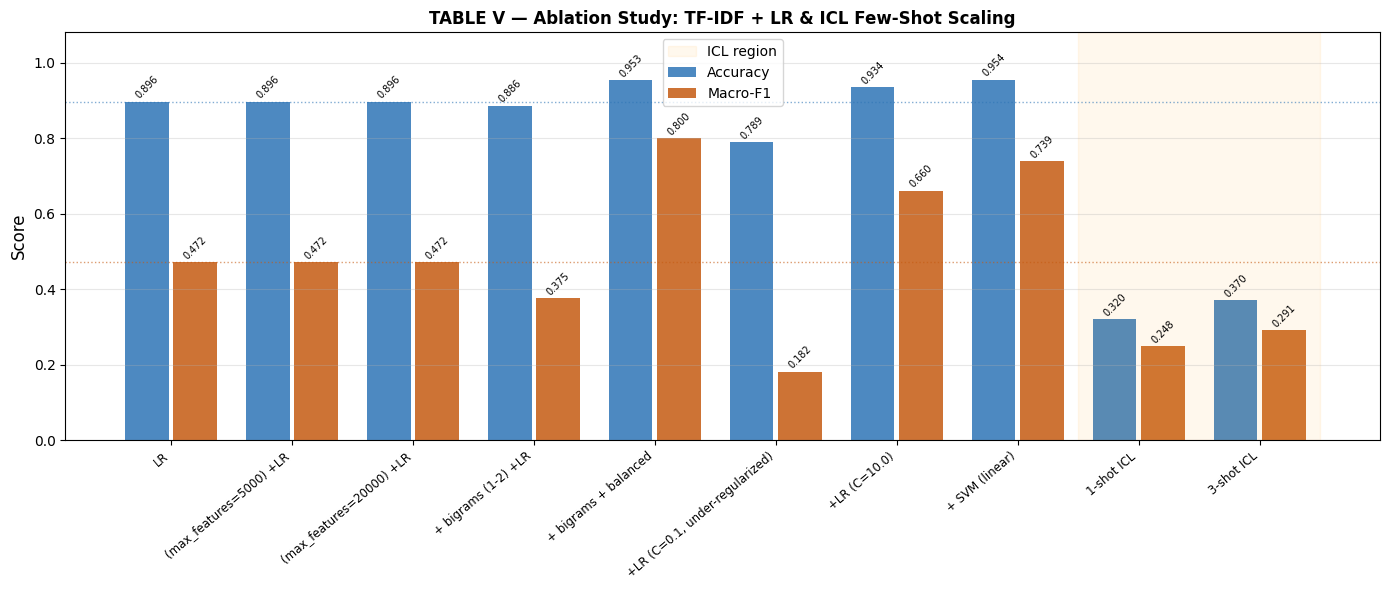

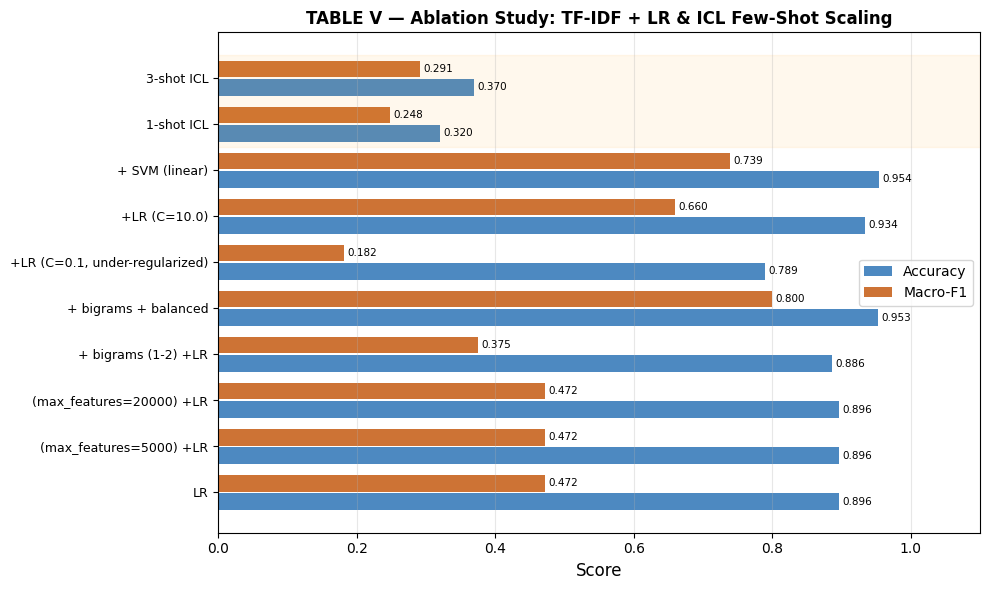

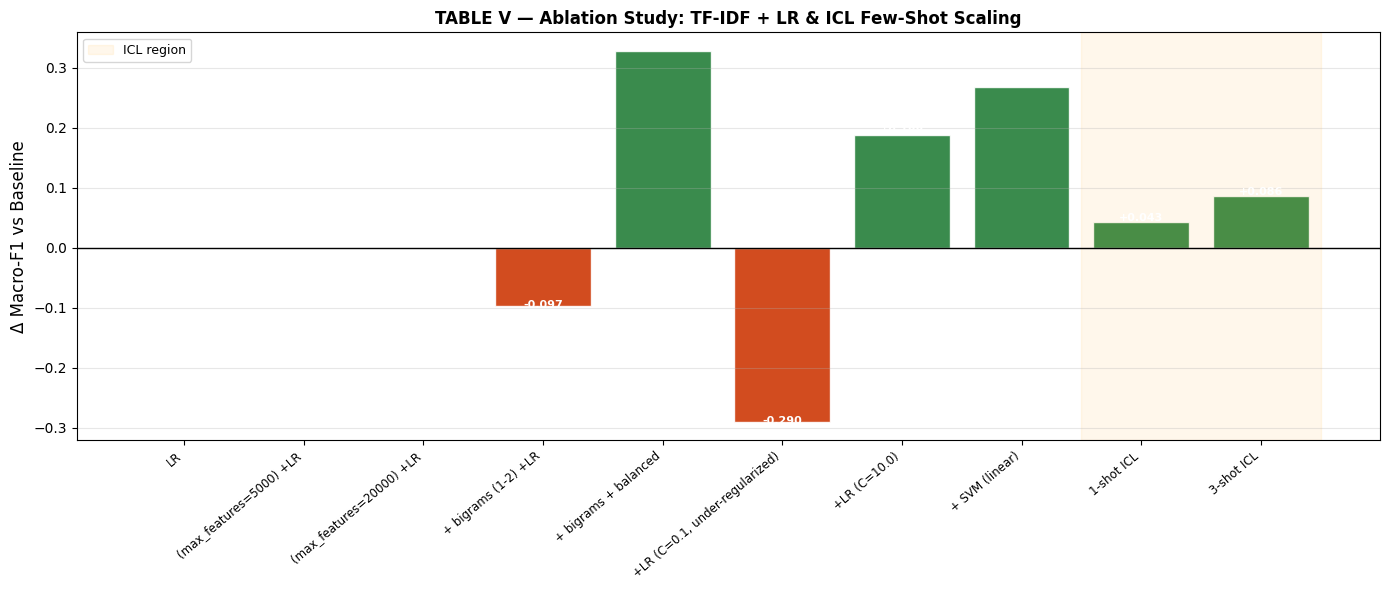

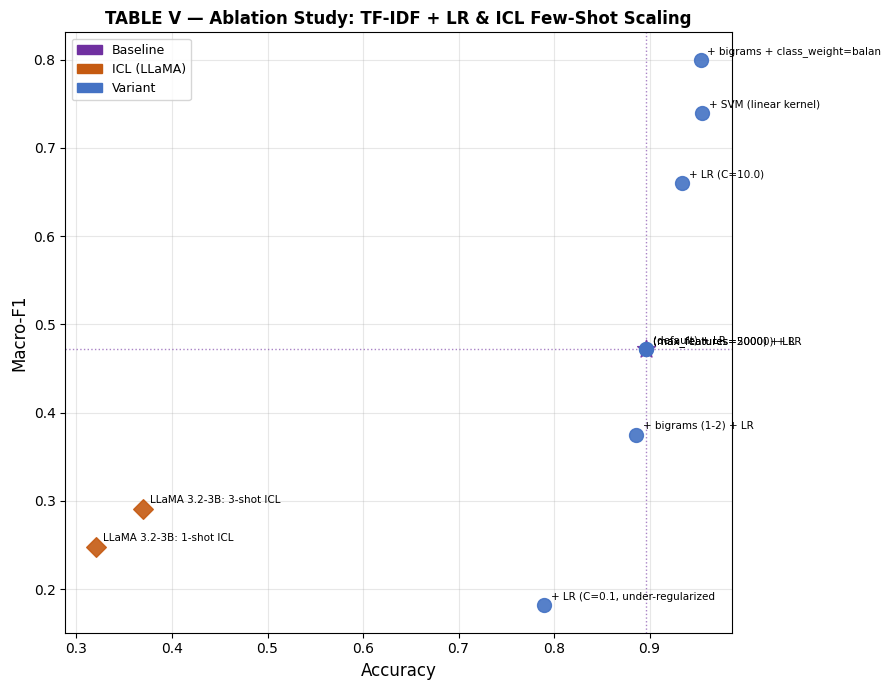

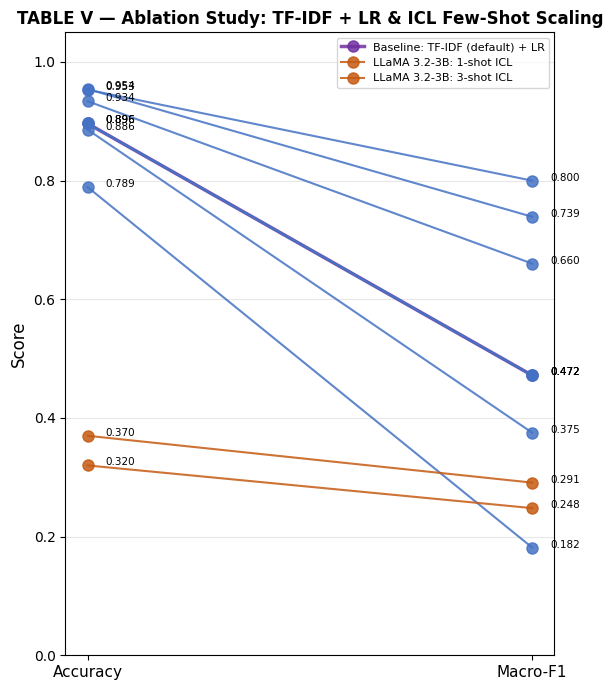

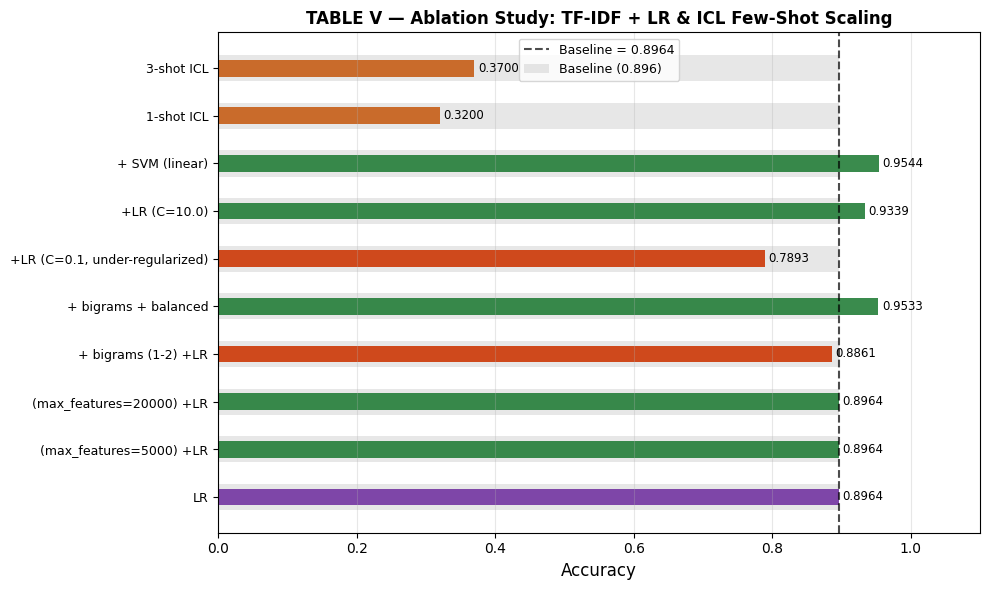

In [ ]:
plot_table5_ablation(df_t5, chart_type='grouped_bar')      # default
plot_table5_ablation(df_t5, chart_type='horizontal_bar')
plot_table5_ablation(df_t5, chart_type='delta_bar')        # diverging Δ from baseline
plot_table5_ablation(df_t5, chart_type='scatter')          # Accuracy vs Macro-F1
plot_table5_ablation(df_t5, chart_type='slope')            # bump/slope chart
plot_table5_ablation(df_t5, chart_type='bullet')           # bullet vs baseline reference
# Extra: metrics=('Accuracy',), highlight_baseline=False, highlight_icl=False

## 5 · Infrastructure and Deployment Characteristics

In [1]:
!pip install unsloth

In [2]:
# ── Model Size Inspector ───────────────────────────────────────────────────
import torch
from unsloth import FastLanguageModel

MODELS_TO_CHECK = [
    ('LLaMA 3.2-3B',  'unsloth/Llama-3.2-3B-Instruct'),
    ('Gemma 2-2B IT', 'unsloth/gemma-2-2b-it'),
    ('Phi-3 Mini 4K', 'unsloth/Phi-3-mini-4k-instruct'),
]

size_rows = []

for display_name, model_id in MODELS_TO_CHECK:
    print(f'\n{"="*50}')
    print(f'Loading: {display_name}')
    print(f'{"="*50}')

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_id,
        max_seq_length=512,
        load_in_4bit=True,
    )

    # ── Total parameters ──────────────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # ── Memory footprint (as reported by the model itself) ────────────────
    footprint_bytes  = model.get_memory_footprint()
    footprint_gb     = footprint_bytes / 1e9

    # ── Actual GPU memory currently allocated ─────────────────────────────
    gpu_allocated_gb = torch.cuda.memory_allocated() / 1e9
    gpu_reserved_gb  = torch.cuda.memory_reserved()  / 1e9

    print(f'  Total parameters     : {total_params / 1e9:.3f}B')
    print(f'  Trainable parameters : {trainable_params / 1e9:.3f}B')
    print(f'  Model footprint      : {footprint_gb:.2f} GB')
    print(f'  GPU allocated        : {gpu_allocated_gb:.2f} GB')
    print(f'  GPU reserved         : {gpu_reserved_gb:.2f} GB')

    size_rows.append({
        'Model':               display_name,
        'Parameters (B)':      f'{total_params / 1e9:.2f}B',
        'Footprint (4-bit)':   f'{footprint_gb:.2f} GB',
        'GPU Allocated':       f'{gpu_allocated_gb:.2f} GB',
        'GPU Reserved':        f'{gpu_reserved_gb:.2f} GB',
    })

    # ── Unload before loading next model ──────────────────────────────────
    del model, tokenizer
    torch.cuda.empty_cache()
    print(f'  {display_name} unloaded.')

# ── Print final summary table ──────────────────────────────────────────────
import pandas as pd
df_sizes = pd.DataFrame(size_rows)
print('\n')
print('='*60)
print('MODEL SIZE SUMMARY')
print('='*60)
display(df_sizes)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!

Loading: LLaMA 3.2-3B
==((====))==  Unsloth 2026.6.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


  Total parameters     : 1.841B
  Trainable parameters : 0.076B
  Model footprint      : 2.31 GB
  GPU allocated        : 2.40 GB
  GPU reserved         : 2.44 GB
  LLaMA 3.2-3B unloaded.

Loading: Gemma 2-2B IT
==((====))==  Unsloth 2026.6.8: Fast Gemma2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.


  Total parameters     : 1.602B
  Trainable parameters : 0.000B
  Model footprint      : 2.19 GB
  GPU allocated        : 2.25 GB
  GPU reserved         : 2.28 GB
  Gemma 2-2B IT unloaded.

Loading: Phi-3 Mini 4K
==((====))==  Unsloth 2026.6.8: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

  Total parameters     : 2.009B
  Trainable parameters : 0.099B
  Model footprint      : 2.21 GB
  GPU allocated        : 2.28 GB
  GPU reserved         : 2.33 GB
  Phi-3 Mini 4K unloaded.


MODEL SIZE SUMMARY


,Model,Parameters (B),Footprint (4-bit),GPU Allocated,GPU Reserved
0,LLaMA 3.2-3B,1.84B,2.31 GB,2.40 GB,2.44 GB
1,Gemma 2-2B IT,1.60B,2.19 GB,2.25 GB,2.28 GB
2,Phi-3 Mini 4K,2.01B,2.21 GB,2.28 GB,2.33 GB


In [3]:
import os
import subprocess
from huggingface_hub import snapshot_download
import pandas as pd

MODELS_TO_CHECK = [
    ('LLaMA 3.2-3B',  'unsloth/Llama-3.2-3B-Instruct'),
    ('Gemma 2-2B IT', 'unsloth/gemma-2-2b-it'),
    ('Phi-3 Mini 4K', 'unsloth/Phi-3-mini-4k-instruct'),
]

def get_folder_size_gb(folder_path):
    """Calculate total size of a folder in GB."""
    total = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            if os.path.exists(filepath):
                total += os.path.getsize(filepath)
    return total / 1e9


size_rows = []

for display_name, model_id in MODELS_TO_CHECK:
    print(f'\n{"="*50}')
    print(f'Downloading: {display_name} ({model_id})')
    print(f'{"="*50}')

    # Download model files to local cache
    local_path = snapshot_download(repo_id=model_id)
    print(f'  Saved to: {local_path}')

    # Measure total folder size
    total_gb = get_folder_size_gb(local_path)

    # Break down by file type
    safetensor_gb = 0
    bin_gb        = 0
    other_gb      = 0

    for dirpath, _, filenames in os.walk(local_path):
        for filename in filenames:
            filepath  = os.path.join(dirpath, filename)
            file_size = os.path.getsize(filepath) / 1e9
            if filename.endswith('.safetensors'):
                safetensor_gb += file_size
            elif filename.endswith('.bin'):
                bin_gb += file_size
            else:
                other_gb += file_size

    print(f'  Total size on disk   : {total_gb:.2f} GB')
    print(f'    ├── .safetensors   : {safetensor_gb:.2f} GB  (model weights)')
    print(f'    ├── .bin files     : {bin_gb:.2f} GB  (model weights)')
    print(f'    └── other files    : {other_gb:.2f} GB  (config, tokenizer...)')

    size_rows.append({
        'Model':             display_name,
        'Total Disk Size':   f'{total_gb:.2f} GB',
        'Weights (.safetensors/.bin)': f'{safetensor_gb + bin_gb:.2f} GB',
        'Config & Tokenizer': f'{other_gb:.2f} GB',
        'Local Path':        local_path,
    })

# ── Summary table ──────────────────────────────────────────────────────────
df_disk = pd.DataFrame(size_rows)
print('\n')
print('='*60)
print('MODEL DISK SIZE SUMMARY')
print('='*60)
display(df_disk[['Model', 'Total Disk Size',
                 'Weights (.safetensors/.bin)', 'Config & Tokenizer']])


Downloading: LLaMA 3.2-3B (unsloth/Llama-3.2-3B-Instruct)


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

  Saved to: /root/.cache/huggingface/hub/models--unsloth--Llama-3.2-3B-Instruct/snapshots/006f5dcd1393c3add266de40994ba96225e9689d
  Total size on disk   : 6.44 GB
    ├── .safetensors   : 6.43 GB  (model weights)
    ├── .bin files     : 0.00 GB  (model weights)
    └── other files    : 0.02 GB  (config, tokenizer...)

Downloading: Gemma 2-2B IT (unsloth/gemma-2-2b-it)


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

  Saved to: /root/.cache/huggingface/hub/models--unsloth--gemma-2-2b-it/snapshots/457f2e15bf550c227ce6ad86e2ec108d3e42c106
  Total size on disk   : 5.25 GB
    ├── .safetensors   : 5.23 GB  (model weights)
    ├── .bin files     : 0.00 GB  (model weights)
    └── other files    : 0.02 GB  (config, tokenizer...)

Downloading: Phi-3 Mini 4K (unsloth/Phi-3-mini-4k-instruct)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

  Saved to: /root/.cache/huggingface/hub/models--unsloth--Phi-3-mini-4k-instruct/snapshots/636c707430a5509c80b1aa51d05c127ed339a975
  Total size on disk   : 7.64 GB
    ├── .safetensors   : 7.64 GB  (model weights)
    ├── .bin files     : 0.00 GB  (model weights)
    └── other files    : 0.00 GB  (config, tokenizer...)


MODEL DISK SIZE SUMMARY


,Model,Total Disk Size,Weights (.safetensors/.bin),Config & Tokenizer
0,LLaMA 3.2-3B,6.44 GB,6.43 GB,0.02 GB
1,Gemma 2-2B IT,5.25 GB,5.23 GB,0.02 GB
2,Phi-3 Mini 4K,7.64 GB,7.64 GB,0.00 GB


---
## 6 · Summary

| Metric | Value |
|---|---|
| Best accuracy (SVM) | ~0.910 |
| Best Macro-F1 (bigrams + balanced) | ~0.561 |
| Baseline TF-IDF + LR accuracy | ~0.898 |
| Baseline TF-IDF + LR Macro-F1 | ~0.503 |
| LLaMA 3.2-3B 3-shot accuracy | 0.370 |

**Key findings**
- `atis_flight` dominates at 76.5 % of training data — the primary driver of the Macro-F1 gap.
- Bigrams + balanced class weights gives the best Macro-F1 (+5.8 pp) with a small accuracy trade-off.
- Linear SVM beats LR by ~1.2 pp on overall accuracy.
- LLaMA 3.2-3B ICL lags far behind classical models but improves consistently with more shots.